# Notebook 4 - Modelado y segmentacion territorial

Este cuaderno desarrolla la fase de modelado del pilar de Analisis del Dato a partir de la tabla municipal agregada generada en el `Notebook 3`.

A diferencia del cuaderno anterior, centrado en el analisis descriptivo y la construccion de indicadores, aqui el objetivo es identificar grupos de municipios con perfiles climaticos, territoriales, sociales y de exposicion fisica similares mediante tecnicas de segmentacion no supervisada.

La entrada principal del notebook es:

`DATA/PROCESSED/dataset_cv_municipios_analisis_municipal.csv`

El enfoque adoptado en esta fase no pretende todavia predecir siniestros reales, sino detectar patrones municipales de riesgo relativo, intensidad climatica, vulnerabilidad territorial y exposicion construida que puedan resultar utiles para la interpretacion posterior y para el Analisis de Negocio.

La segmentacion toma como entrada las variables justificadas en el `Notebook 3`, pero separa dos usos distintos: las variables observables sirven para entrenar los modelos y los scores compuestos se reservan principalmente para interpretar los grupos obtenidos. Esta separacion evita que el clustering reproduzca de forma mecanica una puntuacion heuristica ya calculada.

Como complemento al modelado no supervisado, se incluye un `Random Forest` explicativo del `score_riesgo_exploratorio`. Este bloque no predice siniestralidad real: su objetivo es comprobar que variables observables explican mejor el indice construido y recuperar, de forma honesta, parte del enfoque de modelos basados en arboles previsto en el anteproyecto.

## 0. Configuracion inicial

En este bloque se cargan las librerias necesarias y se definen las rutas de trabajo. El notebook parte de la salida analitica municipal ya construida, por lo que no repite el proceso ETL ni el analisis exploratorio anterior.

Ademas, se preparan las rutas para posibles salidas de modelado, visualizacion y exportacion de resultados.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    r2_score,
    mean_absolute_error,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "DATA"
PROC = DATA / "PROCESSED"
EXT = DATA / "EXTERNAL"
OUT = ROOT / "output"
ANALYSIS_OUT = OUT / "analisis"
MAPS = OUT / "maps"

ANALYTIC_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_analisis_municipal.csv"
MUNICIPIOS_GEO_FILE = EXT / "municipios_cv.geojson"
SEGMENTED_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_segmentado.csv"
ANALYSIS_HANDOFF_FILE = ANALYSIS_OUT / "puente_analisis_modelado.csv"

MODEL_OUT = OUT / "modelado"
MODEL_OUT.mkdir(parents=True, exist_ok=True)
MAPS.mkdir(parents=True, exist_ok=True)

print("Dataset municipal analitico:", ANALYTIC_MUNICIPAL_FILE)
print("Existe:", ANALYTIC_MUNICIPAL_FILE.exists())
print("Geometria municipal disponible:", MUNICIPIOS_GEO_FILE.exists())
print("Directorio de salida:", MODEL_OUT)
print("Puente analisis-modelado disponible:", ANALYSIS_HANDOFF_FILE.exists())
print("Salida segmentada prevista:", SEGMENTED_MUNICIPAL_FILE)

Dataset municipal analitico: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_analisis_municipal.csv
Existe: True
Geometria municipal disponible: True
Directorio de salida: C:\Users\gonza\OneDrive\tfg\output\modelado
Puente analisis-modelado disponible: True
Salida segmentada prevista: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_segmentado.csv


## 1. Objetivo analitico del modelado y carga de la base municipal

El objetivo de esta fase es identificar grupos de municipios con perfiles climaticos y territoriales similares a partir de la tabla agregada construida en el `Notebook 3`. Dado que no se dispone de datos reales de siniestralidad para entrenar un modelo supervisado, el enfoque adoptado se basa en tecnicas de segmentacion no supervisada.

En consecuencia, el modelado no pretende predecir siniestros, sino detectar patrones municipales de riesgo relativo, intensidad climatica y vulnerabilidad territorial. Esta aproximacion permite comparar municipios, construir tipologias y preparar una lectura posterior orientada a negocio.

Antes de seleccionar variables y entrenar modelos, se carga la base municipal analitica y se comprueba que conserva la estructura esperada.


In [2]:
df_mun = pd.read_csv(ANALYTIC_MUNICIPAL_FILE)

print("Shape:", df_mun.shape)
print("Municipios unicos:", df_mun["municipio"].nunique())
print("Columnas:", len(df_mun.columns))
print("Duplicados municipales:", df_mun.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum())

assert df_mun["municipio"].nunique() == 542, "La base analitica debe conservar 542 municipios."
assert df_mun.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum() == 0, "Hay duplicados municipales."

key_cols = [
    "municipio",
    "precip_p99",
    "dias_precip_extrema",
    "temp_p95",
    "dias_calor_intenso",
    "viento_p95",
    "dias_suelo_seco",
    "dias_radiacion_alta",
    "dias_runoff_extremo",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
    "densidad_edificios_km2",
    "densidad_viviendas_catastro_km2",
    "ratio_huella_edificada_pct",
    "snczi_inundacion_t100_pct_area_aprox",
    "snczi_inundacion_t500_pct_area_aprox",
    "altitud_m",
    "score_exposicion_construida",
    "score_exposicion_inundacion",
    "score_exposicion_fisica",
    "score_riesgo_exploratorio",
    "contrib_peligro_climatico",
    "contrib_vulnerabilidad",
    "contrib_exposicion_fisica",
    "dimension_dominante_score",
]

print("Columnas principales disponibles:")
print([col for col in key_cols if col in df_mun.columns])

display(df_mun[[col for col in key_cols if col in df_mun.columns]].head())

if ANALYSIS_HANDOFF_FILE.exists():
    analysis_modeling_handoff = pd.read_csv(ANALYSIS_HANDOFF_FILE)
    print("Puente metodologico desde Notebook 3:")
    display(analysis_modeling_handoff)
else:
    print("No se encontro puente analisis-modelado; se continua con la base analitica municipal.")

Shape: (542, 110)
Municipios unicos: 542
Columnas: 110
Duplicados municipales: 0
Columnas principales disponibles:
['municipio', 'precip_p99', 'dias_precip_extrema', 'temp_p95', 'dias_calor_intenso', 'viento_p95', 'dias_suelo_seco', 'dias_radiacion_alta', 'dias_runoff_extremo', 'densidad_poblacion', 'mayores_65_pct', 'renta_media_hogar', 'densidad_edificios_km2', 'densidad_viviendas_catastro_km2', 'ratio_huella_edificada_pct', 'snczi_inundacion_t100_pct_area_aprox', 'snczi_inundacion_t500_pct_area_aprox', 'altitud_m', 'score_exposicion_construida', 'score_exposicion_inundacion', 'score_exposicion_fisica', 'score_riesgo_exploratorio', 'contrib_peligro_climatico', 'contrib_vulnerabilidad', 'contrib_exposicion_fisica', 'dimension_dominante_score']


,municipio,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,altitud_m,score_exposicion_construida,score_exposicion_inundacion,score_exposicion_fisica,score_riesgo_exploratorio,contrib_peligro_climatico,contrib_vulnerabilidad,contrib_exposicion_fisica,dimension_dominante_score
0,Ademuz,18.368174,6,32.069465,60,6.782720,0,250,88,10.12,26.80,27809.0,20.51,14.38,0.1728,0.000000,0.000000,907.0,0.002188,0.000000,0.001313,0.244092,0.114680,0.129149,0.000263,vulnerabilidad
1,Ador,37.833611,38,31.999384,68,7.682318,537,225,145,126.84,20.42,31572.0,65.19,70.97,1.0499,0.004943,0.018251,79.0,0.011108,0.012747,0.011764,0.366768,0.259976,0.104439,0.002353,peligro climatico
2,Agost,18.520694,11,32.961835,97,7.184352,1505,284,62,78.39,20.27,30407.0,35.77,43.79,0.8237,0.004800,0.005891,181.0,0.007359,0.006009,0.006819,0.301895,0.193872,0.106660,0.001364,peligro climatico
3,Agres,31.017301,28,34.419501,176,5.725050,0,244,114,24.10,24.80,31440.0,25.65,23.64,0.4122,0.000000,0.000000,756.0,0.004014,0.000000,0.002408,0.310747,0.194846,0.115419,0.000482,peligro climatico
4,Agullent,28.305807,25,34.757147,200,5.912659,84,244,123,150.09,21.43,31085.0,78.74,72.46,2.7882,0.002691,0.002990,556.0,0.020919,0.003200,0.013832,0.312086,0.201058,0.108261,0.002766,peligro climatico


Puente metodologico desde Notebook 3:


,bloque,variables_clave,uso_en_modelado,precaucion
0,Variables climaticas y contexto fisico,"precip_p99, dias_precip_extrema, dias_calor_in...",Base para segmentar municipios por amenaza cli...,No equivalen a siniestralidad real; proceden d...
1,Vulnerabilidad territorial,"densidad_poblacion, mayores_65_pct, renta_medi...",Diferenciar municipios con sensibilidad social...,"Son proxies agregados municipales, no informac..."
2,Exposicion fisica,"score_exposicion_construida, score_exposicion_...",Separar concentracion construida y exposicion ...,No mide capital asegurado ni dano observado.
3,Score exploratorio,"score_riesgo_exploratorio, contrib_peligro_cli...","Ordenar municipios, explicar drivers y contras...",Score heuristico calibrable en el futuro con s...


## 2. Seleccion de variables para la segmentacion

La segmentacion se construye a partir de variables observables, no de los scores compuestos generados en el `Notebook 3`. Esto evita que el modelo agrupe municipios a partir de una puntuacion ya calculada de forma heuristica y permite que los clusters se expliquen desde dimensiones mas directas: peligro climatico base, contexto climatico extendido, vulnerabilidad social, exposicion construida, exposicion a inundacion y condicion territorial.

La seleccion mantiene un equilibrio entre riqueza analitica e interpretabilidad. Se incorporan las nuevas variables de `ERA5-Land` extendido, `Catastro` y `SNCZI`, pero no se incluyen todas las columnas disponibles para no sobredimensionar el modelo ni introducir redundancia excesiva. En particular, de `SNCZI` entran solo los porcentajes municipales agregados `T100` y `T500`; se excluyen pixeles, resolucion y banderas booleanas porque son trazabilidad tecnica o versiones discretizadas de la misma senal.

La idea clave es que el modelo agrupe por perfiles observables, mientras que los scores se utilizan despues como variables de lectura: ayudan a nombrar e interpretar clusters, pero no fuerzan la particion.

,bloque,variable,dimension,origen,motivo_inclusion,limitacion
0,peligro_climatico_base,precip_p99,Amenaza climatica directa,ERA5-Land base,"Recoge extremos y frecuencia de precipitacion,...",Varios municipios pueden compartir celda clima...
1,peligro_climatico_base,dias_precip_extrema,Amenaza climatica directa,ERA5-Land base,"Recoge extremos y frecuencia de precipitacion,...",Varios municipios pueden compartir celda clima...
2,peligro_climatico_base,temp_p95,Amenaza climatica directa,ERA5-Land base,"Recoge extremos y frecuencia de precipitacion,...",Varios municipios pueden compartir celda clima...
3,peligro_climatico_base,dias_calor_intenso,Amenaza climatica directa,ERA5-Land base,"Recoge extremos y frecuencia de precipitacion,...",Varios municipios pueden compartir celda clima...
4,peligro_climatico_base,viento_p95,Amenaza climatica directa,ERA5-Land base,"Recoge extremos y frecuencia de precipitacion,...",Varios municipios pueden compartir celda clima...
5,contexto_climatico_extendido,dias_suelo_seco,Contexto fisico complementario,ERA5-Land extendido,"Anade sequedad, radiacion, escorrentia y humed...","Aporta contexto, no causalidad aseguradora dir..."
6,contexto_climatico_extendido,dias_radiacion_alta,Contexto fisico complementario,ERA5-Land extendido,"Anade sequedad, radiacion, escorrentia y humed...","Aporta contexto, no causalidad aseguradora dir..."
7,contexto_climatico_extendido,dias_runoff_extremo,Contexto fisico complementario,ERA5-Land extendido,"Anade sequedad, radiacion, escorrentia y humed...","Aporta contexto, no causalidad aseguradora dir..."
8,contexto_climatico_extendido,humedad_suelo_media_periodo,Contexto fisico complementario,ERA5-Land extendido,"Anade sequedad, radiacion, escorrentia y humed...","Aporta contexto, no causalidad aseguradora dir..."
9,vulnerabilidad_social,densidad_poblacion,Vulnerabilidad territorial,INE,"Aproxima densidad, envejecimiento y capacidad ...",No contiene informacion individual ni cartera ...


,tipo_variable,ejemplos,decision,motivo
0,Scores compuestos,"score_riesgo_exploratorio, score_peligro_clima...",No entran en el ajuste KMeans/Agglomerative,Ya combinan variables con pesos heuristicos; s...
1,Componentes derivados del score,"contrib_peligro_climatico, contrib_vulnerabili...",No entran en el ajuste KMeans/Agglomerative,Sirven para explicar por que un municipio o cl...
2,Identificadores y geometria directa,"municipio, CODNUT2, CODNUT3, lat, lon",No entran en el ajuste principal,"Identifican o localizan el municipio, pero no ..."
3,Trazabilidad tecnica SNCZI,"snczi_pixeles_muestra_municipio, snczi_resoluc...",No entran en el ajuste principal,Son metadatos de calculo o versiones discretiz...
4,Variables muy redundantes,medias y maximos alternativos ya representados...,Se dejan fuera de la matriz final,Reducen interpretabilidad y pueden duplicar se...


Variables seleccionadas para segmentacion: 18
- precip_p99
- dias_precip_extrema
- temp_p95
- dias_calor_intenso
- viento_p95
- dias_suelo_seco
- dias_radiacion_alta
- dias_runoff_extremo
- humedad_suelo_media_periodo
- densidad_poblacion
- mayores_65_pct
- renta_media_hogar
- densidad_edificios_km2
- densidad_viviendas_catastro_km2
- ratio_huella_edificada_pct
- snczi_inundacion_t100_pct_area_aprox
- snczi_inundacion_t500_pct_area_aprox
- altitud_m


,count,mean,std,min,25%,50%,75%,max
precip_p99,542.0,26.927875,5.382713,16.445655,23.357834,26.765683,29.846917,40.481348
dias_precip_extrema,542.0,21.920664,8.175929,5.000000,16.000000,21.000000,28.000000,41.000000
temp_p95,542.0,32.880859,1.551139,28.335553,31.729986,32.938959,34.163996,36.000543
dias_calor_intenso,542.0,109.605166,71.350680,3.000000,50.000000,101.000000,164.000000,306.000000
viento_p95,542.0,6.972567,0.719757,5.408023,6.516475,6.907734,7.409866,9.511220
dias_suelo_seco,542.0,219.201107,353.033904,0.000000,0.000000,0.000000,373.000000,1582.000000
dias_radiacion_alta,542.0,219.206642,34.235481,152.000000,194.000000,221.000000,240.000000,301.000000
dias_runoff_extremo,542.0,109.605166,32.764874,40.000000,90.250000,108.000000,123.000000,250.000000
humedad_suelo_media_periodo,542.0,0.238132,0.038816,0.108358,0.223183,0.236090,0.251813,0.336209
densidad_poblacion,542.0,580.056642,2055.248495,0.680000,15.990000,87.810000,397.387500,24305.560000


Correlaciones entre variables seleccionadas:


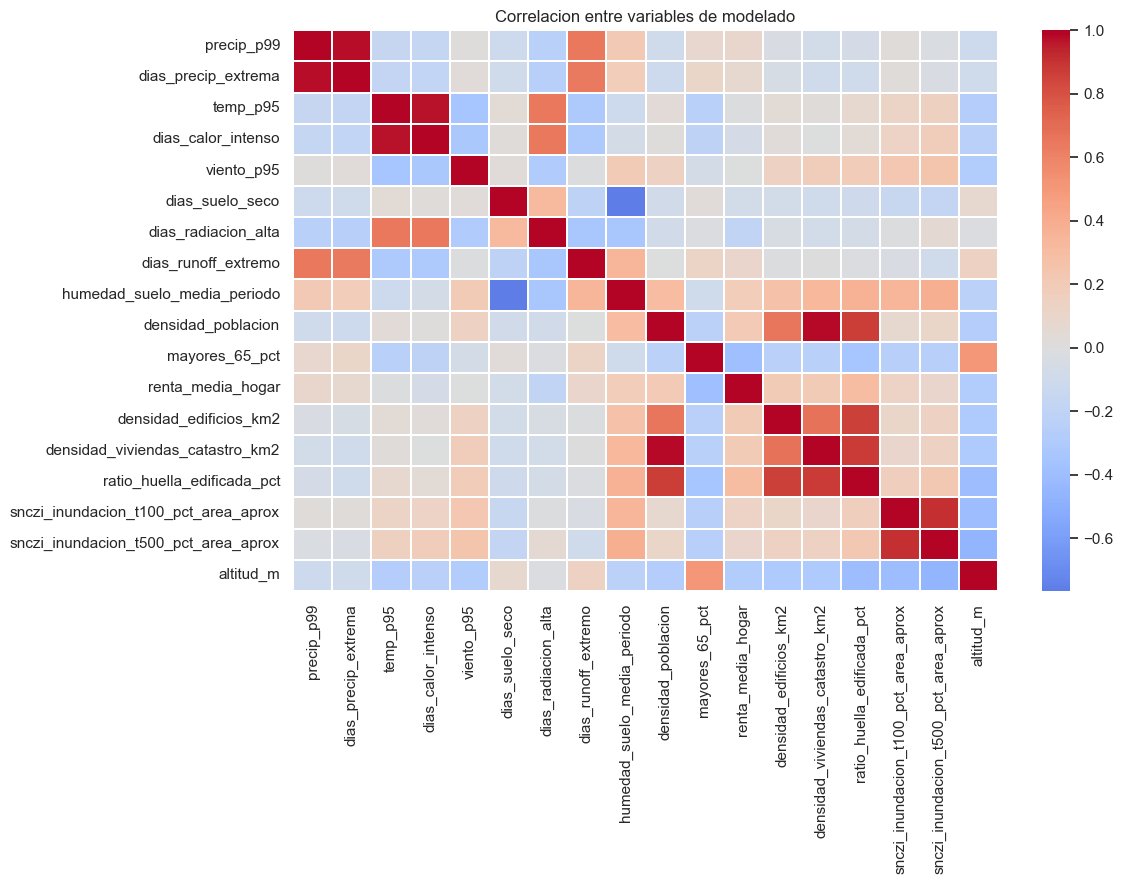

In [3]:
feature_groups = {
    "peligro_climatico_base": [
        "precip_p99",
        "dias_precip_extrema",
        "temp_p95",
        "dias_calor_intenso",
        "viento_p95",
    ],
    "contexto_climatico_extendido": [
        "dias_suelo_seco",
        "dias_radiacion_alta",
        "dias_runoff_extremo",
        "humedad_suelo_media_periodo",
    ],
    "vulnerabilidad_social": [
        "densidad_poblacion",
        "mayores_65_pct",
        "renta_media_hogar",
    ],
    "exposicion_fisica_catastro": [
        "densidad_edificios_km2",
        "densidad_viviendas_catastro_km2",
        "ratio_huella_edificada_pct",
    ],
    "exposicion_inundacion_snczi": [
        "snczi_inundacion_t100_pct_area_aprox",
        "snczi_inundacion_t500_pct_area_aprox",
    ],
    "condicion_fisica": [
        "altitud_m",
    ],
}

feature_group_metadata = {
    "peligro_climatico_base": {
        "dimension": "Amenaza climatica directa",
        "origen": "ERA5-Land base",
        "motivo": "Recoge extremos y frecuencia de precipitacion, calor y viento.",
        "limitacion": "Varios municipios pueden compartir celda climatica.",
    },
    "contexto_climatico_extendido": {
        "dimension": "Contexto fisico complementario",
        "origen": "ERA5-Land extendido",
        "motivo": "Anade sequedad, radiacion, escorrentia y humedad de suelo.",
        "limitacion": "Aporta contexto, no causalidad aseguradora directa.",
    },
    "vulnerabilidad_social": {
        "dimension": "Vulnerabilidad territorial",
        "origen": "INE",
        "motivo": "Aproxima densidad, envejecimiento y capacidad economica.",
        "limitacion": "No contiene informacion individual ni cartera asegurada.",
    },
    "exposicion_fisica_catastro": {
        "dimension": "Exposicion construida",
        "origen": "Catastro INSPIRE BU Buildings",
        "motivo": "Introduce concentracion de edificios, viviendas y huella edificada.",
        "limitacion": "No equivale a capital asegurado ni valor de poliza.",
    },
    "exposicion_inundacion_snczi": {
        "dimension": "Exposicion hidrologica territorial",
        "origen": "SNCZI / IDEE",
        "motivo": "Introduce proporcion aproximada del municipio en zonas inundables T100 y T500.",
        "limitacion": "Es una aproximacion rasterizada municipal; no sustituye cartografia oficial de detalle.",
    },
    "condicion_fisica": {
        "dimension": "Control territorial",
        "origen": "Open-Meteo/IGN",
        "motivo": "La altitud ayuda a explicar gradientes climaticos y territoriales.",
        "limitacion": "No debe dominar por si sola la segmentacion.",
    },
}

model_features = [col for cols in feature_groups.values() for col in cols]
missing_features = [col for col in model_features if col not in df_mun.columns]
if missing_features:
    raise ValueError(f"Faltan variables necesarias para el modelado: {missing_features}")

feature_catalog = []
for group, cols in feature_groups.items():
    meta = feature_group_metadata[group]
    for col in cols:
        feature_catalog.append(
            {
                "bloque": group,
                "variable": col,
                "dimension": meta["dimension"],
                "origen": meta["origen"],
                "motivo_inclusion": meta["motivo"],
                "limitacion": meta["limitacion"],
            }
        )

feature_catalog = pd.DataFrame(feature_catalog)
feature_catalog.to_csv(MODEL_OUT / "model_feature_catalog.csv", index=False)
display(feature_catalog)

excluded_model_inputs = pd.DataFrame(
    [
        {
            "tipo_variable": "Scores compuestos",
            "ejemplos": "score_riesgo_exploratorio, score_peligro_climatico_ampliado, score_exposicion_inundacion",
            "decision": "No entran en el ajuste KMeans/Agglomerative",
            "motivo": "Ya combinan variables con pesos heuristicos; se usan para interpretar clusters, no para entrenarlos.",
        },
        {
            "tipo_variable": "Componentes derivados del score",
            "ejemplos": "contrib_peligro_climatico, contrib_vulnerabilidad, dimension_dominante_score",
            "decision": "No entran en el ajuste KMeans/Agglomerative",
            "motivo": "Sirven para explicar por que un municipio o cluster queda priorizado, no para definir la distancia entre municipios.",
        },
        {
            "tipo_variable": "Identificadores y geometria directa",
            "ejemplos": "municipio, CODNUT2, CODNUT3, lat, lon",
            "decision": "No entran en el ajuste principal",
            "motivo": "Identifican o localizan el municipio, pero no describen por si mismas el perfil de riesgo.",
        },
        {
            "tipo_variable": "Trazabilidad tecnica SNCZI",
            "ejemplos": "snczi_pixeles_muestra_municipio, snczi_resolucion_px, *_pixeles_inundables, *_tiene_zona_inundable",
            "decision": "No entran en el ajuste principal",
            "motivo": "Son metadatos de calculo o versiones discretizadas de la misma senal territorial.",
        },
        {
            "tipo_variable": "Variables muy redundantes",
            "ejemplos": "medias y maximos alternativos ya representados por percentiles/frecuencias",
            "decision": "Se dejan fuera de la matriz final",
            "motivo": "Reducen interpretabilidad y pueden duplicar senales ya capturadas por otras variables.",
        },
    ]
)

excluded_model_inputs.to_csv(MODEL_OUT / "model_feature_exclusions.csv", index=False)
display(excluded_model_inputs)

print("Variables seleccionadas para segmentacion:", len(model_features))
for col in model_features:
    print("-", col)

display(df_mun[model_features].describe().T)

print("Correlaciones entre variables seleccionadas:")
plt.figure(figsize=(12, 9))
sns.heatmap(
    df_mun[model_features].corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
)
plt.title("Correlacion entre variables de modelado")
plt.tight_layout()
plt.show()

## 3. Preparacion del dataset para modelado

Antes de aplicar tecnicas de segmentacion, se prepara la matriz de variables que utilizara el modelo. Esta fase incluye la comprobacion de nulos, la imputacion simple de valores faltantes, una transformacion logaritmica en variables muy asimetricas y la estandarizacion final.

La transformacion logaritmica se aplica solo a variables territoriales y de Catastro con colas muy largas, como densidad de poblacion o densidad edificada. Con ello se evita que unos pocos municipios muy urbanos dominen artificialmente la distancia entre observaciones.

In [4]:
X_raw = df_mun[model_features].copy()

print("Shape matriz original:", X_raw.shape)
print("Nulos por variable:")
display(X_raw.isna().sum().to_frame("nulos"))

# Imputacion simple para no perder municipios en esta fase exploratoria.
X_filled = X_raw.fillna(X_raw.median(numeric_only=True))

log_transform_cols = [
    "densidad_poblacion",
    "densidad_edificios_km2",
    "densidad_viviendas_catastro_km2",
    "ratio_huella_edificada_pct",
]
log_transform_cols = [col for col in log_transform_cols if col in X_filled.columns]

X_model = X_filled.copy()
for col in log_transform_cols:
    X_model[col] = np.log1p(X_model[col].clip(lower=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)
X_scaled = pd.DataFrame(X_scaled, columns=model_features, index=df_mun.index)

preprocessing_audit = []
for col in model_features:
    raw_series = pd.to_numeric(X_raw[col], errors="coerce")
    preprocessing_audit.append(
        {
            "variable": col,
            "bloque": feature_catalog.loc[feature_catalog["variable"] == col, "bloque"].iloc[0],
            "nulos_originales": int(raw_series.isna().sum()),
            "pct_nulos_originales": round(raw_series.isna().mean() * 100, 2),
            "imputacion": "mediana municipal" if raw_series.isna().any() else "sin imputacion",
            "valor_imputacion": round(float(X_raw[col].median(skipna=True)), 6),
            "transformacion": "log1p tras imputacion" if col in log_transform_cols else "sin transformacion logaritmica",
            "media_tras_preprocesado": round(float(X_model[col].mean()), 6),
            "std_tras_preprocesado": round(float(X_model[col].std()), 6),
        }
    )

preprocessing_audit = pd.DataFrame(preprocessing_audit)
preprocessing_audit.to_csv(MODEL_OUT / "model_preprocessing_audit.csv", index=False)

print("Variables con transformacion log1p:", log_transform_cols)
print("Shape matriz escalada:", X_scaled.shape)
display(preprocessing_audit)
display(X_scaled.head())

Shape matriz original: (542, 18)
Nulos por variable:


,nulos
precip_p99,0
dias_precip_extrema,0
temp_p95,0
dias_calor_intenso,0
viento_p95,0
dias_suelo_seco,0
dias_radiacion_alta,0
dias_runoff_extremo,0
humedad_suelo_media_periodo,0
densidad_poblacion,0


Variables con transformacion log1p: ['densidad_poblacion', 'densidad_edificios_km2', 'densidad_viviendas_catastro_km2', 'ratio_huella_edificada_pct']
Shape matriz escalada: (542, 18)


,variable,bloque,nulos_originales,pct_nulos_originales,imputacion,valor_imputacion,transformacion,media_tras_preprocesado,std_tras_preprocesado
0,precip_p99,peligro_climatico_base,0,0.00,sin imputacion,26.765683,sin transformacion logaritmica,26.927875,5.382713
1,dias_precip_extrema,peligro_climatico_base,0,0.00,sin imputacion,21.000000,sin transformacion logaritmica,21.920664,8.175929
2,temp_p95,peligro_climatico_base,0,0.00,sin imputacion,32.938959,sin transformacion logaritmica,32.880859,1.551139
3,dias_calor_intenso,peligro_climatico_base,0,0.00,sin imputacion,101.000000,sin transformacion logaritmica,109.605166,71.350680
4,viento_p95,peligro_climatico_base,0,0.00,sin imputacion,6.907734,sin transformacion logaritmica,6.972567,0.719757
5,dias_suelo_seco,contexto_climatico_extendido,0,0.00,sin imputacion,0.000000,sin transformacion logaritmica,219.201107,353.033904
6,dias_radiacion_alta,contexto_climatico_extendido,0,0.00,sin imputacion,221.000000,sin transformacion logaritmica,219.206642,34.235481
7,dias_runoff_extremo,contexto_climatico_extendido,0,0.00,sin imputacion,108.000000,sin transformacion logaritmica,109.605166,32.764874
8,humedad_suelo_media_periodo,contexto_climatico_extendido,0,0.00,sin imputacion,0.236090,sin transformacion logaritmica,0.238132,0.038816
9,densidad_poblacion,vulnerabilidad_social,0,0.00,sin imputacion,87.810000,log1p tras imputacion,4.505200,1.947519


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,altitud_m
0,-1.591690,-1.949059,-0.523579,-0.695873,-0.264010,-0.621480,0.900288,-0.660009,0.464709,-1.077469,0.271044,-0.869622,-0.819725,-0.923212,-0.965828,-0.418462,-0.457859,1.597053
1,2.027938,1.968484,-0.568801,-0.583647,0.987008,0.901025,0.169377,1.081266,0.076188,0.177610,-0.641131,-0.043213,0.132548,0.016588,-0.276101,-0.379960,-0.355772,-0.934539
2,-1.563328,-1.336943,0.052252,-0.176828,0.294516,3.645505,1.894328,-1.454275,-3.346416,-0.067238,-0.662578,-0.299064,-0.365481,-0.272239,-0.420524,-0.381074,-0.424907,-0.622676
3,0.760435,0.744252,0.992859,0.931402,-1.734849,-0.621480,0.724870,0.134256,0.091765,-0.659052,-0.014904,-0.072202,-0.638192,-0.636187,-0.736385,-0.418462,-0.457859,1.135374
4,0.256229,0.376982,1.210736,1.268080,-1.473953,-0.383323,0.724870,0.409195,-0.290664,0.263489,-0.496727,-0.150165,0.290334,0.029068,0.482429,-0.397501,-0.441134,0.523878


### 3.1 Diagnostico visual mediante PCA

La proyeccion `PCA` no se utiliza como modelo final, sino como herramienta de diagnostico. Permite representar en dos dimensiones una matriz de variables mas amplia y comprobar si existen gradientes o agrupaciones razonables antes de aplicar los algoritmos de clustering.

,componente,varianza_explicada_pct
0,PC1,32.84
1,PC2,19.80


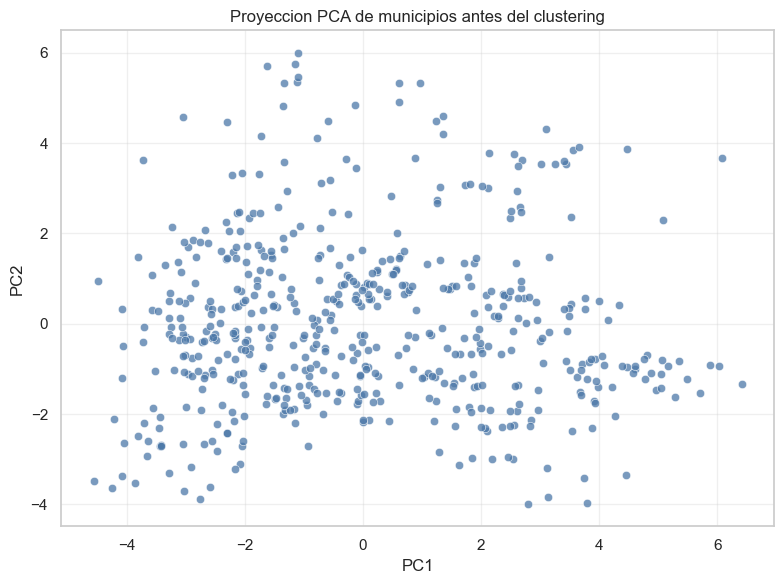

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_mun["pca_1"] = X_pca[:, 0]
df_mun["pca_2"] = X_pca[:, 1]

pca_explained = pd.DataFrame(
    {
        "componente": ["PC1", "PC2"],
        "varianza_explicada_pct": (pca.explained_variance_ratio_ * 100).round(2),
    }
)

display(pca_explained)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_mun, x="pca_1", y="pca_2", color="#4c78a8", alpha=0.75)
plt.title("Proyeccion PCA de municipios antes del clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Primer modelo: KMeans y seleccion del numero de clusters

Como primer enfoque de segmentacion se aplica `KMeans`, una tecnica no supervisada que busca agrupar observaciones en funcion de su proximidad en el espacio de variables. En este contexto, el objetivo es identificar conjuntos de municipios con perfiles climaticos, sociales y de exposicion similares.

Dado que `KMeans` requiere fijar previamente el numero de clusters, se prueban varios valores de `k` y se comparan mediante distintas metricas de adecuacion. Esta fase no persigue optimizar un unico criterio matematico de forma aislada, sino encontrar una segmentacion razonable tanto desde el punto de vista cuantitativo como interpretativo.

In [6]:
k_values = range(2, 8)
kmeans_results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = model.fit_predict(X_scaled)

    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    kmeans_results.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
            "cluster_min_size": cluster_sizes.min(),
            "cluster_max_size": cluster_sizes.max(),
        }
    )

df_kmeans_eval = pd.DataFrame(kmeans_results)
display(df_kmeans_eval)

  File "C:\Users\gonza\OneDrive\tfg\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,inertia,silhouette,davies_bouldin,calinski_harabasz,cluster_min_size,cluster_max_size
0,2,7412.828327,0.236835,1.685862,170.692298,210,332
1,3,6457.762824,0.194345,1.718841,137.644405,149,242
2,4,5712.318495,0.192238,1.551184,126.947908,65,205
3,5,5188.488652,0.206758,1.567635,118.182469,48,197
4,6,4802.463169,0.184460,1.628665,110.572248,46,143
5,7,4414.784086,0.203562,1.464028,107.878077,27,148


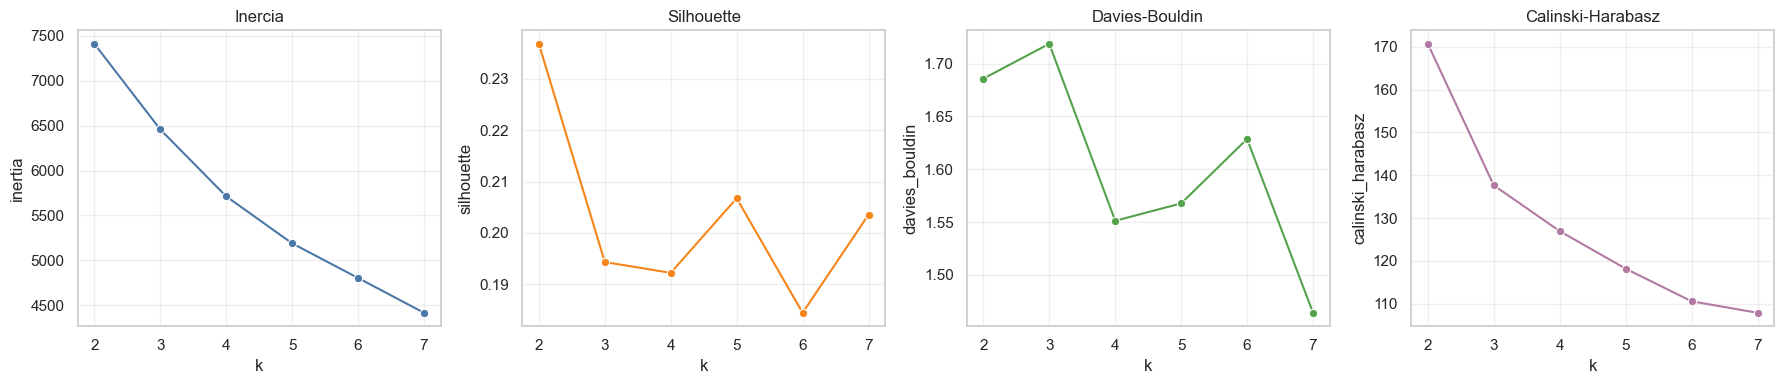

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.lineplot(data=df_kmeans_eval, x="k", y="inertia", marker="o", ax=axes[0], color="#4c78a8")
axes[0].set_title("Inercia")

sns.lineplot(data=df_kmeans_eval, x="k", y="silhouette", marker="o", ax=axes[1], color="#f58518")
axes[1].set_title("Silhouette")

sns.lineplot(data=df_kmeans_eval, x="k", y="davies_bouldin", marker="o", ax=axes[2], color="#54a24b")
axes[2].set_title("Davies-Bouldin")

sns.lineplot(data=df_kmeans_eval, x="k", y="calinski_harabasz", marker="o", ax=axes[3], color="#b279a2")
axes[3].set_title("Calinski-Harabasz")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 4.1 Decision sobre el numero de clusters

La eleccion de `k` se documenta como una decision multicriterio. Las metricas internas aportan una referencia cuantitativa, pero tambien se revisa el tamano minimo de los grupos y la facilidad para traducir los perfiles a una lectura territorial.

In [8]:
df_kmeans_decision = df_kmeans_eval.copy()
df_kmeans_decision["rank_silhouette"] = df_kmeans_decision["silhouette"].rank(ascending=False, method="min").astype(int)
df_kmeans_decision["rank_davies_bouldin"] = df_kmeans_decision["davies_bouldin"].rank(ascending=True, method="min").astype(int)
df_kmeans_decision["rank_calinski_harabasz"] = df_kmeans_decision["calinski_harabasz"].rank(ascending=False, method="min").astype(int)
df_kmeans_decision["cluster_min_size_pct"] = (df_kmeans_decision["cluster_min_size"] / len(df_mun) * 100).round(1)
df_kmeans_decision["lectura"] = np.select(
    [
        df_kmeans_decision["k"] == 2,
        df_kmeans_decision["k"] == 3,
        df_kmeans_decision["k"] == 4,
        df_kmeans_decision["k"].isin([5, 6, 7]),
    ],
    [
        "Demasiado agregado; mezcla perfiles territoriales distintos.",
        "Mejora la lectura, pero todavia agrupa perfiles amplios.",
        "Equilibrio entre metricas, tamanos e interpretabilidad.",
        "Aporta matices, pero fragmenta el territorio y aparecen grupos pequenos.",
    ],
    default="Revision adicional necesaria",
)

display(
    df_kmeans_decision[
        [
            "k",
            "silhouette",
            "davies_bouldin",
            "calinski_harabasz",
            "cluster_min_size",
            "cluster_min_size_pct",
            "rank_silhouette",
            "rank_davies_bouldin",
            "rank_calinski_harabasz",
            "lectura",
        ]
    ]
)

,k,silhouette,davies_bouldin,calinski_harabasz,cluster_min_size,cluster_min_size_pct,rank_silhouette,rank_davies_bouldin,rank_calinski_harabasz,lectura
0,2,0.236835,1.685862,170.692298,210,38.7,1,5,1,Demasiado agregado; mezcla perfiles territoria...
1,3,0.194345,1.718841,137.644405,149,27.5,4,6,2,"Mejora la lectura, pero todavia agrupa perfile..."
2,4,0.192238,1.551184,126.947908,65,12.0,5,2,3,"Equilibrio entre metricas, tamanos e interpret..."
3,5,0.206758,1.567635,118.182469,48,8.9,2,3,4,"Aporta matices, pero fragmenta el territorio y..."
4,6,0.184460,1.628665,110.572248,46,8.5,6,4,5,"Aporta matices, pero fragmenta el territorio y..."
5,7,0.203562,1.464028,107.878077,27,5.0,3,1,6,"Aporta matices, pero fragmenta el territorio y..."


La seleccion del numero de clusters se apoya en varios criterios complementarios. En general, valores altos de `silhouette` y `calinski_harabasz`, junto con valores bajos de `davies_bouldin`, sugieren una mejor separacion interna. Aun asi, en este TFG tambien importa que la solucion sea interpretable, que los grupos tengan un tamano suficiente y que los perfiles puedan explicarse desde variables climaticas, sociales y de exposicion.

Con la matriz ampliada de variables, `k=4` ofrece el equilibrio mas razonable. `k=2` y `k=3` son mas simples, pero demasiado agregados para distinguir perfiles territoriales utiles. `k=5`, `k=6` y `k=7` reducen inercia, como es esperable al aumentar grupos, pero empiezan a fragmentar el territorio y generan clusters pequenos. Por eso `k=4` se selecciona como solucion principal: no es el optimo unico de todas las metricas, sino la alternativa mas defendible entre calidad interna, estabilidad e interpretabilidad.

## 5. Ajuste final de KMeans e interpretacion de clusters

Una vez comparados varios valores posibles de `k`, se selecciona una configuracion final de `KMeans` para analizar con mayor detalle los perfiles resultantes. A partir de esta segmentacion, se asigna a cada municipio un cluster y se estudian las diferencias medias entre grupos en las variables climaticas y territoriales seleccionadas.

El objetivo de esta fase no es solo obtener una particion del dataset, sino interpretar el significado de cada cluster y valorar si la segmentacion resulta util para distinguir tipologias municipales con implicaciones analiticas y territoriales.


In [9]:
k_final = 4

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=50)
df_mun["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)

print("Numero de clusters:", k_final)
print("Tamano de cada cluster:")
display(df_mun["cluster_kmeans"].value_counts().sort_index().to_frame("municipios"))

Numero de clusters: 4
Tamano de cada cluster:


,municipios
cluster_kmeans,
0,141
1,205
2,131
3,65


In [10]:
cluster_profile = (
    df_mun.groupby("cluster_kmeans")[model_features]
    .mean()
    .round(2)
)

display(cluster_profile)


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,altitud_m
cluster_kmeans,,,,,,,,,,,,,,,,,,
0,27.46,22.43,32.69,95.62,7.44,106.67,205.75,114.04,0.27,1878.68,19.70,34886.40,312.52,956.36,8.23,0.17,0.24,76.32
1,26.35,21.45,31.79,61.77,6.96,179.21,200.36,113.53,0.23,28.16,29.71,29963.94,27.51,25.64,0.39,0.00,0.00,633.32
2,31.04,27.82,34.14,164.67,6.47,172.61,233.63,123.18,0.23,142.40,23.69,32188.80,70.43,81.26,1.51,0.01,0.02,353.17
3,19.32,10.42,34.22,179.83,7.02,683.34,278.78,60.28,0.19,385.68,23.48,29742.37,99.58,227.69,2.41,0.04,0.11,332.74


In [11]:
cluster_profile_scaled = (
    df_mun.groupby("cluster_kmeans")[model_features]
    .mean()
)

cluster_profile_scaled = (
    (cluster_profile_scaled - cluster_profile_scaled.mean())
    / cluster_profile_scaled.std()
).round(2)

display(cluster_profile_scaled)


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,altitud_m
cluster_kmeans,,,,,,,,,,,,,,,,,,
0,0.29,0.26,-0.44,-0.53,1.17,-0.67,-0.67,0.39,1.15,1.48,-1.07,1.33,1.46,1.47,1.46,1.46,1.35,-1.20
1,0.06,0.13,-1.20,-1.14,-0.03,-0.40,-0.82,0.38,0.07,-0.68,1.35,-0.72,-0.79,-0.69,-0.79,-0.72,-0.84,1.25
2,1.02,1.00,0.79,0.70,-1.27,-0.42,0.11,0.71,0.08,-0.54,-0.11,0.21,-0.45,-0.56,-0.46,-0.55,-0.67,0.02
3,-1.37,-1.39,0.86,0.97,0.13,1.49,1.37,-1.48,-1.30,-0.26,-0.16,-0.81,-0.22,-0.22,-0.21,-0.19,0.16,-0.07


### 5.1 Lectura territorial de los clusters KMeans

La tabla siguiente traduce cada etiqueta numerica de `KMeans` a una lectura territorial. Esta interpretacion se apoya en los perfiles medios, en las variables normalizadas y en los scores del `Notebook 3`, pero mantiene la cautela de que los clusters no son categorias reales de siniestralidad.

In [12]:
cluster_interpretation = pd.DataFrame(
    [
        {
            "cluster_kmeans": 0,
            "perfil_territorial": "Areas urbanas o litorales con exposicion fisica e inundable elevada",
            "rasgos_dominantes": "Mayor densidad poblacional y edificada, baja altitud y mayor porcentaje medio en zonas inundables SNCZI.",
            "lectura_riesgo": "Perfil clave para negocio por concentracion de activos y exposicion territorial; no implica siniestralidad real observada.",
        },
        {
            "cluster_kmeans": 1,
            "perfil_territorial": "Interior rural de baja exposicion fisica y mayor altitud",
            "rasgos_dominantes": "Baja densidad poblacional y edificada, baja exposicion inundable, mayor altitud y envejecimiento relativo.",
            "lectura_riesgo": "Riesgo exploratorio menor, pero con vulnerabilidad territorial que conviene no ignorar.",
        },
        {
            "cluster_kmeans": 2,
            "perfil_territorial": "Municipios con peligro climatico alto y exposicion fisica moderada-baja",
            "rasgos_dominantes": "Precipitacion extrema, calor y contexto fisico elevados, con densidades construidas inferiores a las zonas urbanas.",
            "lectura_riesgo": "Grupo importante para vigilancia de amenazas climaticas combinadas, especialmente en lectura preventiva.",
        },
        {
            "cluster_kmeans": 3,
            "perfil_territorial": "Municipios calidos y secos con exposicion hidrologica moderada",
            "rasgos_dominantes": "Alta frecuencia de calor intenso, suelo seco, radiacion alta y exposicion inundable intermedia, con menor precipitacion extrema.",
            "lectura_riesgo": "Perfil util para diferenciar estres termico/sequedad de la exposicion urbana mas concentrada.",
        },
    ]
)

display(cluster_interpretation)

,cluster_kmeans,perfil_territorial,rasgos_dominantes,lectura_riesgo
0,0,Areas urbanas o litorales con exposicion fisic...,"Mayor densidad poblacional y edificada, baja a...",Perfil clave para negocio por concentracion de...
1,1,Interior rural de baja exposicion fisica y may...,"Baja densidad poblacional y edificada, baja ex...","Riesgo exploratorio menor, pero con vulnerabil..."
2,2,Municipios con peligro climatico alto y exposi...,"Precipitacion extrema, calor y contexto fisico...",Grupo importante para vigilancia de amenazas c...
3,3,Municipios calidos y secos con exposicion hidr...,"Alta frecuencia de calor intenso, suelo seco, ...",Perfil util para diferenciar estres termico/se...


In [13]:
display(
    df_mun[
        ["municipio", "cluster_kmeans"] + model_features
    ]
    .sort_values(["cluster_kmeans", "municipio"])
    .head(30)
)


,municipio,cluster_kmeans,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,altitud_m
9,Alaquàs,0,23.357834,16,33.381610,122,7.154692,0,201,88,0.230774,7813.20,21.15,32487.0,634.83,3365.28,32.3449,0.025316,0.054852,72.0
11,Albal,0,24.561298,17,33.280024,120,7.412632,0,197,113,0.327783,2367.58,14.78,35455.0,301.32,1016.29,11.4530,0.161765,0.282353,13.0
12,Albalat de la Ribera,0,28.848063,25,34.167437,170,7.321437,0,213,110,0.310025,243.98,20.49,30619.0,111.29,138.02,1.7774,0.552090,0.873544,11.0
13,Albalat dels Sorells,0,22.825924,15,32.756757,91,7.046315,596,192,88,0.205994,938.75,20.71,38697.0,201.59,428.76,5.3125,0.000000,0.002535,81.0
16,Alberic,0,29.846917,28,34.827740,201,6.793810,0,225,112,0.257979,414.06,18.79,31085.0,136.09,219.32,3.4504,0.242341,0.244530,24.0
19,Alboraia/Alboraya,0,24.168112,18,33.107392,108,7.594843,0,194,117,0.336209,3144.92,17.74,44525.0,276.63,1608.07,10.7497,0.021965,0.027168,0.0
20,Albuixech,0,24.168112,18,33.107392,108,7.594843,0,194,117,0.336209,1027.30,21.91,37531.0,228.98,462.99,12.1387,0.231681,0.258621,0.0
28,Alcàntera de Xúquer,0,30.225485,25,35.470624,231,6.749098,0,226,107,0.235948,428.48,20.53,30078.0,191.47,221.83,3.5413,0.186161,0.413509,160.0
29,Alcàsser,0,24.561298,17,33.280024,120,7.412632,0,197,113,0.327783,1204.29,17.59,32990.0,237.68,529.81,8.9951,0.066955,0.156048,13.0
30,Aldaia,0,23.357834,16,33.381610,122,7.154692,0,201,88,0.230774,2146.15,16.08,33692.0,224.41,879.59,11.1761,0.092774,0.188522,72.0


La solucion final con `k=4` permite observar grupos de municipios con combinaciones diferenciadas de precipitacion extrema, calor, viento, contexto fisico, exposicion edificada, exposicion inundable, altitud y vulnerabilidad social. La lectura de los perfiles medios facilita interpretar cada cluster no solo como una etiqueta numerica, sino como una tipologia territorial con caracteristicas climaticas, socioeconomicas, constructivas e hidrologicas propias.

El punto fuerte de `KMeans` en este TFG es su equilibrio entre simplicidad e interpretabilidad: produce cuatro perfiles suficientemente distintos para ser utiles, pero no tan fragmentados como para dificultar la lectura territorial. En esta fase, la utilidad principal del modelo reside en resumir la heterogeneidad municipal en un numero reducido de grupos que despues puedan analizarse en mapas y traducirse a implicaciones de negocio.

## 6. Representacion espacial e interpretacion territorial de KMeans

Una vez asignado un cluster a cada municipio, resulta necesario trasladar la segmentacion al espacio geografico para comprobar si los grupos obtenidos muestran coherencia territorial. Esta representacion permite detectar si los clusters aparecen de forma dispersa o si, por el contrario, tienden a concentrarse en determinadas zonas con perfiles climaticos y territoriales compartidos.

La lectura espacial del modelo es especialmente relevante en este TFG, ya que el objetivo no es solo agrupar municipios desde un punto de vista estadistico, sino interpretar si esas agrupaciones pueden entenderse como tipologias territoriales de riesgo relativo.


In [14]:
gdf_mun = gpd.read_file(MUNICIPIOS_GEO_FILE)

map_feature_cols = [
    "score_riesgo_exploratorio",
    "score_peligro_climatico_ampliado",
    "score_vulnerabilidad",
    "score_exposicion_construida",
    "score_exposicion_inundacion",
    "score_exposicion_fisica",
]
map_feature_cols = [col for col in map_feature_cols if col in df_mun.columns]

gdf_kmeans = gdf_mun.merge(
    df_mun[["municipio", "CODNUT2", "CODNUT3", "cluster_kmeans"] + map_feature_cols + model_features],
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

print("Municipios en geometria:", len(gdf_mun))
print("Municipios con cluster:", gdf_kmeans["cluster_kmeans"].notna().sum())
display(gdf_kmeans[["municipio", "cluster_kmeans"] + map_feature_cols].head())

Municipios en geometria: 542
Municipios con cluster: 542


,municipio,cluster_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_construida,score_exposicion_inundacion,score_exposicion_fisica
0,l'Atzúbia,2,0.405777,0.519953,0.483333,0.006673,0.000000,0.004004
1,Agost,3,0.301895,0.387744,0.355532,0.007359,0.006009,0.006819
2,Agres,2,0.310747,0.389693,0.384731,0.004014,0.000000,0.002408
3,Aigües,3,0.272103,0.341875,0.334659,0.006399,0.000000,0.003839
4,Albatera,3,0.291777,0.375189,0.329444,0.014116,0.045697,0.026748


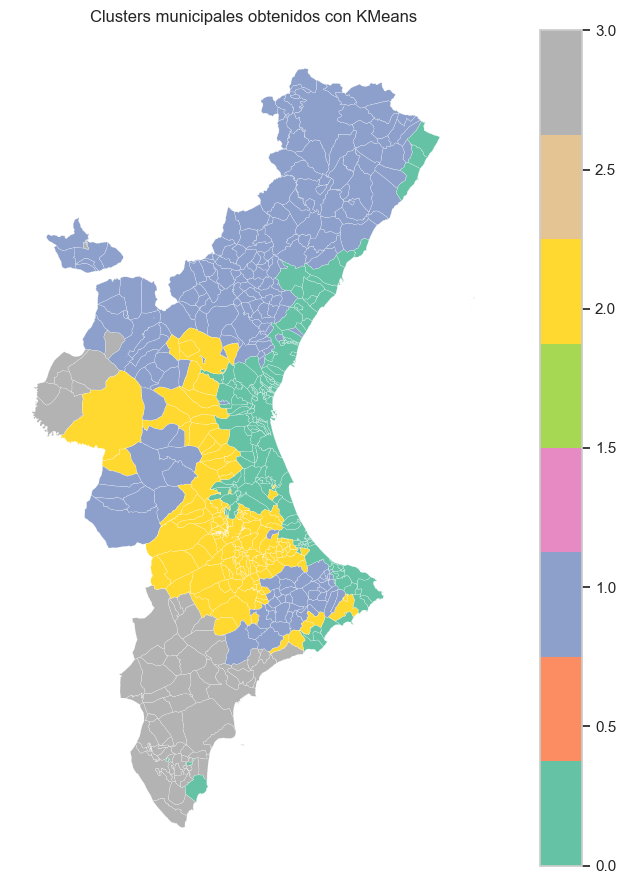

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_kmeans.plot(
    column="cluster_kmeans",
    cmap="Set2",
    legend=True,
    ax=ax,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)

ax.set_title("Clusters municipales obtenidos con KMeans")
ax.axis("off")
plt.tight_layout()
plt.show()


In [16]:
cluster_summary_features = model_features + [
    "score_peligro_climatico_ampliado",
    "score_vulnerabilidad",
    "score_exposicion_construida",
    "score_exposicion_inundacion",
    "score_exposicion_fisica",
    "score_riesgo_exploratorio",
    "contrib_peligro_climatico",
    "contrib_vulnerabilidad",
    "contrib_exposicion_fisica",
]
cluster_summary_features = [col for col in cluster_summary_features if col in df_mun.columns]

cluster_summary_agg = {"municipios": ("municipio", "count")}
cluster_summary_agg.update({col: (col, "mean") for col in cluster_summary_features})

cluster_summary = (
    df_mun.groupby("cluster_kmeans")
    .agg(**cluster_summary_agg)
    .round(2)
)

display(cluster_summary)

,municipios,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,altitud_m,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_construida,score_exposicion_inundacion,score_exposicion_fisica,score_riesgo_exploratorio,contrib_peligro_climatico,contrib_vulnerabilidad,contrib_exposicion_fisica
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,141,27.46,22.43,32.69,95.62,7.44,106.67,205.75,114.04,0.27,1878.68,19.70,34886.40,312.52,956.36,8.23,0.17,0.24,76.32,0.37,0.34,0.09,0.23,0.15,0.32,0.19,0.10,0.03
1,205,26.35,21.45,31.79,61.77,6.96,179.21,200.36,113.53,0.23,28.16,29.71,29963.94,27.51,25.64,0.39,0.00,0.00,633.32,0.31,0.44,0.00,0.00,0.00,0.29,0.15,0.13,0.00
2,131,31.04,27.82,34.14,164.67,6.47,172.61,233.63,123.18,0.23,142.40,23.69,32188.80,70.43,81.26,1.51,0.01,0.02,353.17,0.43,0.37,0.01,0.02,0.02,0.33,0.22,0.11,0.00
3,65,19.32,10.42,34.22,179.83,7.02,683.34,278.78,60.28,0.19,385.68,23.48,29742.37,99.58,227.69,2.41,0.04,0.11,332.74,0.39,0.39,0.03,0.08,0.05,0.32,0.20,0.12,0.01


### 6.1 Descomposicion del score por cluster

El `Notebook 3` descompone el `score_riesgo_exploratorio` en tres aportaciones: peligro climatico, vulnerabilidad territorial y exposicion fisica. En este punto se cruza esa descomposicion con los clusters para interpretar mejor que dimension explica el riesgo medio de cada grupo.

Esta lectura no modifica el entrenamiento del modelo: se calcula despues de asignar clusters y funciona como herramienta de explicacion para conectar la segmentacion con el analisis de negocio.

In [17]:
score_contribution_cols = [
    "contrib_peligro_climatico",
    "contrib_vulnerabilidad",
    "contrib_exposicion_fisica",
]
score_contribution_cols = [col for col in score_contribution_cols if col in df_mun.columns]

if score_contribution_cols and "dimension_dominante_score" in df_mun.columns:
    cluster_score_decomposition = (
        df_mun.groupby("cluster_kmeans")
        .agg(
            municipios=("municipio", "count"),
            riesgo_medio=("score_riesgo_exploratorio", "mean"),
            peligro_climatico_medio=("contrib_peligro_climatico", "mean"),
            vulnerabilidad_media=("contrib_vulnerabilidad", "mean"),
            exposicion_fisica_media=("contrib_exposicion_fisica", "mean"),
        )
        .round(3)
    )
    display(cluster_score_decomposition)

    dominant_dimension_by_cluster = pd.crosstab(
        df_mun["cluster_kmeans"],
        df_mun["dimension_dominante_score"],
        normalize="index",
    ).mul(100).round(1)
    display(dominant_dimension_by_cluster)
else:
    print("La descomposicion del score no esta disponible en la base analitica municipal.")

,municipios,riesgo_medio,peligro_climatico_medio,vulnerabilidad_media,exposicion_fisica_media
cluster_kmeans,,,,,
0,141,0.317,0.186,0.102,0.029
1,205,0.286,0.154,0.131,0.001
2,131,0.330,0.216,0.111,0.003
3,65,0.324,0.197,0.118,0.010


dimension_dominante_score,peligro climatico,vulnerabilidad
cluster_kmeans,,
0,97.2,2.8
1,71.7,28.3
2,100.0,0.0
3,100.0,0.0


La descomposicion por cluster refuerza la lectura territorial de la segmentacion. El cluster `2` presenta el mayor `score_riesgo_exploratorio` medio y tambien la mayor contribucion media de peligro climatico, por lo que su interpretacion se apoya principalmente en amenazas climaticas. El cluster `0` concentra la mayor exposicion fisica media, tanto por variables de Catastro como por exposicion inundable `SNCZI`, y por ello representa el perfil mas relevante desde una lectura de activos expuestos. El cluster `1` queda como perfil de menor exposicion fisica, aunque mantiene una vulnerabilidad territorial apreciable, mientras que el cluster `3` ayuda a separar municipios con calor, sequedad y exposicion hidrologica moderada.

Esta lectura confirma que los clusters no solo separan municipios por valores medios, sino que tambien ayudan a explicar que componente del score exploratorio pesa mas en cada perfil territorial.

La representacion espacial permite valorar si los clusters identificados por `KMeans` presentan continuidad o concentracion territorial, algo especialmente importante en un problema geoespacial como el del presente TFG. Si los grupos muestran patrones espaciales reconocibles, la segmentacion gana interpretabilidad y utilidad para fases posteriores de analisis y negocio.

Ademas, la tabla resumen por cluster facilita traducir cada grupo a un perfil territorial concreto, combinando intensidad climatica, vulnerabilidad demografica, contexto socioeconomico, exposicion construida y exposicion a inundacion. Esta lectura resulta clave para pasar de una clasificacion puramente estadistica a una interpretacion aplicada del territorio.

## 7. Segundo modelo: Agglomerative Clustering

Como contraste frente a `KMeans`, se aplica un segundo enfoque de segmentacion no supervisada basado en `Agglomerative Clustering`. A diferencia de `KMeans`, este metodo no parte de centroides, sino de una logica jerarquica que va agrupando observaciones en funcion de su proximidad.

El objetivo de este segundo modelo no es reemplazar automaticamente al primero, sino comprobar si la estructura municipal detectada resulta estable bajo un enfoque alternativo y si los grupos obtenidos mantienen una interpretacion territorial razonable.


In [18]:
agg_model = AgglomerativeClustering(n_clusters=k_final)
df_mun["cluster_agg"] = agg_model.fit_predict(X_scaled)

print("Numero de clusters:", k_final)
print("Tamano de cada cluster:")
display(df_mun["cluster_agg"].value_counts().sort_index().to_frame("municipios"))

Numero de clusters: 4
Tamano de cada cluster:


,municipios
cluster_agg,
0,256
1,51
2,132
3,103


In [19]:
agg_labels = df_mun["cluster_agg"]

agg_metrics = pd.DataFrame(
    [
        {
            "modelo": "Agglomerative",
            "silhouette": silhouette_score(X_scaled, agg_labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, agg_labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, agg_labels),
        }
    ]
)

display(agg_metrics)


,modelo,silhouette,davies_bouldin,calinski_harabasz
0,Agglomerative,0.18804,1.576617,110.738589


In [20]:
agg_profile = (
    df_mun.groupby("cluster_agg")[model_features]
    .mean()
    .round(2)
)

display(agg_profile)


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,altitud_m
cluster_agg,,,,,,,,,,,,,,,,,,
0,25.86,20.70,32.26,82.36,6.92,207.42,208.64,109.62,0.23,38.45,28.48,30315.31,31.10,30.26,0.50,0.00,0.00,613.53
1,18.88,9.76,34.13,180.67,7.09,631.18,284.14,53.22,0.20,578.60,22.37,29535.08,136.85,351.50,3.31,0.07,0.17,172.02
2,27.94,23.23,32.47,84.57,7.49,124.30,202.80,113.36,0.27,1906.90,19.92,35040.54,314.03,959.65,8.22,0.15,0.22,93.64
3,32.25,29.29,34.34,174.22,6.38,166.13,234.35,132.67,0.24,226.49,23.67,32228.08,87.48,128.17,2.07,0.04,0.05,294.06


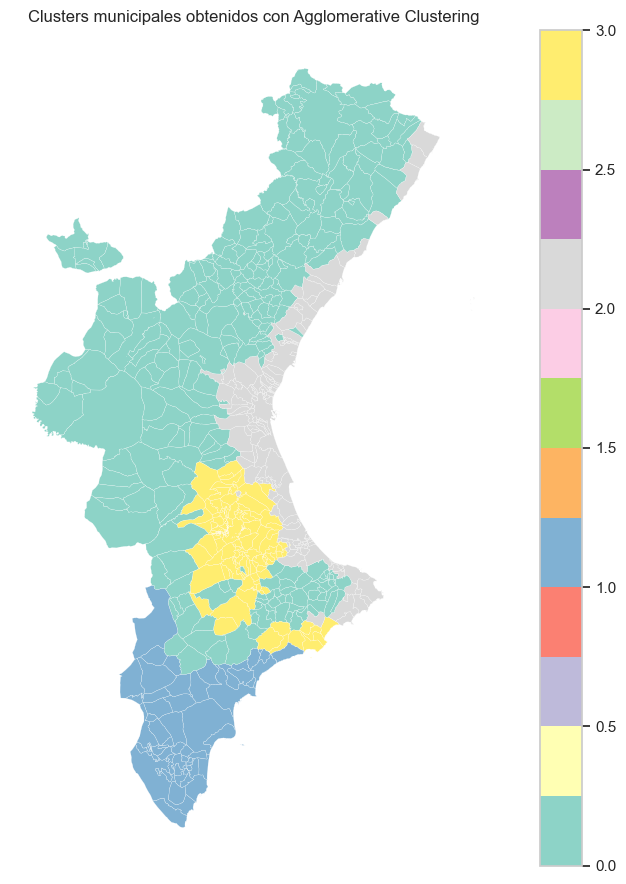

In [21]:
gdf_agg = gdf_mun.merge(
    df_mun[["municipio", "CODNUT2", "CODNUT3", "cluster_agg"]],
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_agg.plot(
    column="cluster_agg",
    cmap="Set3",
    legend=True,
    ax=ax,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)

ax.set_title("Clusters municipales obtenidos con Agglomerative Clustering")
ax.axis("off")
plt.tight_layout()
plt.show()

### 7.1 Estabilidad relativa frente al enfoque jerarquico

Para que el modelo principal sea defendible, no basta con que sus metricas sean razonables: tambien interesa comprobar si otro algoritmo detecta una estructura compatible. La siguiente comparacion no exige que ambos modelos asignen exactamente las mismas etiquetas, pero ayuda a valorar si existe estabilidad metodologica.

In [22]:
kmeans_agg_agreement = pd.crosstab(
    df_mun["cluster_kmeans"],
    df_mun["cluster_agg"],
    rownames=["KMeans"],
    colnames=["Agglomerative"],
)

ari_kmeans_agg = adjusted_rand_score(df_mun["cluster_kmeans"], df_mun["cluster_agg"])

print("Adjusted Rand Index KMeans vs Agglomerative:", round(ari_kmeans_agg, 3))
display(kmeans_agg_agreement)

Adjusted Rand Index KMeans vs Agglomerative: 0.622


Agglomerative,0,1,2,3
KMeans,,,,
0,3,3,120,15
1,201,0,1,3
2,35,0,11,85
3,17,48,0,0


El segundo modelo permite comprobar si la segmentacion territorial observada con `KMeans` se mantiene bajo un enfoque jerarquico alternativo. La comparacion entre ambos resultados resulta util para evaluar la estabilidad de los patrones municipales detectados y para valorar que modelo ofrece una lectura mas interpretable del territorio.

En esta fase, el interes no reside unicamente en la calidad numerica de las metricas, sino tambien en la capacidad del modelo para generar grupos coherentes desde el punto de vista geografico, climatico y territorial. Si `Agglomerative Clustering` confirma parcialmente la estructura general pero resulta menos directo de explicar, su papel natural es el de contraste metodologico y no el de salida principal.

## 8. Tercer enfoque exploratorio: DBSCAN espacial

Ademas de comparar `KMeans` con un modelo jerarquico, se incorpora una prueba exploratoria con `DBSCAN`. Este algoritmo resulta interesante para el TFG porque no obliga a fijar previamente el numero de grupos y permite detectar concentraciones espaciales densas, dejando como ruido aquellos municipios que no encajan claramente en ningun patron local.

En este caso no se utiliza como modelo principal de segmentacion, sino como contraste orientado a la deteccion de posibles zonas densas de riesgo. Para mantener una lectura territorial clara, se emplean la longitud, la latitud y el `score_riesgo_exploratorio`, todos ellos estandarizados antes del ajuste.

In [23]:
dbscan_features = ["lon", "lat", "score_riesgo_exploratorio"]
X_dbscan_raw = df_mun[dbscan_features].copy()
X_dbscan = StandardScaler().fit_transform(X_dbscan_raw)

dbscan_eps = 0.40
dbscan_min_samples = 5

dbscan_model = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)
df_mun["cluster_dbscan"] = dbscan_model.fit_predict(X_dbscan)

dbscan_counts = df_mun["cluster_dbscan"].value_counts().sort_index().to_frame("municipios")
n_dbscan_clusters = len(set(df_mun["cluster_dbscan"]) - {-1})
n_dbscan_noise = int((df_mun["cluster_dbscan"] == -1).sum())
dbscan_noise_pct = n_dbscan_noise / len(df_mun) * 100

print("Parametros DBSCAN:", {"eps": dbscan_eps, "min_samples": dbscan_min_samples})
print("Clusters densos detectados:", n_dbscan_clusters)
print(f"Municipios clasificados como ruido: {n_dbscan_noise} ({dbscan_noise_pct:.1f}%)")
display(dbscan_counts)

Parametros DBSCAN: {'eps': 0.4, 'min_samples': 5}
Clusters densos detectados: 3
Municipios clasificados como ruido: 59 (10.9%)


,municipios
cluster_dbscan,
-1,59
0,437
1,40
2,6


In [24]:
dbscan_core_mask = df_mun["cluster_dbscan"] != -1

if n_dbscan_clusters >= 2 and dbscan_core_mask.sum() > n_dbscan_clusters:
    X_dbscan_core = X_dbscan[dbscan_core_mask]
    dbscan_labels_core = df_mun.loc[dbscan_core_mask, "cluster_dbscan"]
    dbscan_metrics = pd.DataFrame(
        [
            {
                "modelo": "DBSCAN (core)",
                "silhouette": silhouette_score(X_dbscan_core, dbscan_labels_core),
                "davies_bouldin": davies_bouldin_score(X_dbscan_core, dbscan_labels_core),
                "calinski_harabasz": calinski_harabasz_score(X_dbscan_core, dbscan_labels_core),
                "clusters": n_dbscan_clusters,
                "ruido_pct": dbscan_noise_pct,
            }
        ]
    )
else:
    dbscan_metrics = pd.DataFrame(
        [
            {
                "modelo": "DBSCAN (core)",
                "silhouette": np.nan,
                "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan,
                "clusters": n_dbscan_clusters,
                "ruido_pct": dbscan_noise_pct,
            }
        ]
    )

display(dbscan_metrics)

dbscan_profile_cols = [
    "score_riesgo_exploratorio",
    "score_peligro_climatico_ampliado",
    "score_vulnerabilidad",
    "score_exposicion_fisica",
    "lon",
    "lat",
]

dbscan_profile = (
    df_mun.groupby("cluster_dbscan")[dbscan_profile_cols]
    .agg(["count", "mean"])
    .round(3)
)

display(dbscan_profile)

,modelo,silhouette,davies_bouldin,calinski_harabasz,clusters,ruido_pct
0,DBSCAN (core),0.23636,0.824759,62.931582,3,10.885609


score_riesgo_exploratorio         \
                                   count   mean   
cluster_dbscan                                    
-1                                    59  0.331   
 0                                   437  0.307   
 1                                    40  0.309   
 2                                     6  0.245   

               score_peligro_climatico_ampliado        score_vulnerabilidad  \
                                          count   mean                count   
cluster_dbscan                                                                
-1                                           59  0.354                   59   
 0                                          437  0.368                  437   
 1                                           40  0.361                   40   
 2                                            6  0.259                    6   

                      score_exposicion_fisica          lon          lat  \
                 mean                   count   mean count   mean count   
cluster_dbscan                                                            
-1              0.459                      59  0.083    59 -0.800    59   
 0              0.378                     437  0.049   437 -0.441   437   
 1              0.425                      40  0.004    40  0.038    40   
 2              0.377                       6  0.012     6  0.067     6   

                        
                  mean  
cluster_dbscan          
-1              39.368  
 0              39.183  
 1              40.495  
 2              40.167

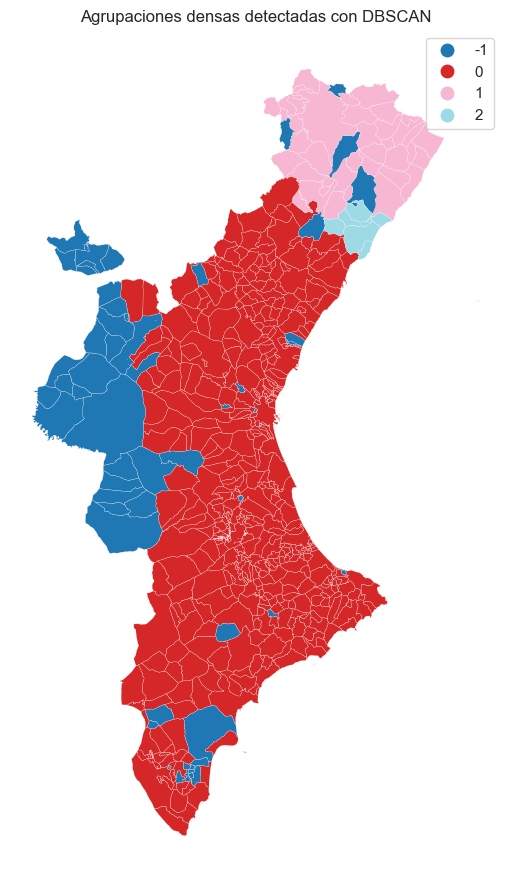

In [25]:
gdf_dbscan = gdf_mun.merge(
    df_mun[["municipio", "CODNUT2", "CODNUT3", "cluster_dbscan", "score_riesgo_exploratorio"]],
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_dbscan.plot(
    column="cluster_dbscan",
    cmap="tab20",
    categorical=True,
    legend=True,
    ax=ax,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)

ax.set_title("Agrupaciones densas detectadas con DBSCAN")
ax.axis("off")
plt.tight_layout()
plt.show()

La lectura de `DBSCAN` debe hacerse con prudencia. El algoritmo aporta valor porque permite identificar concentraciones espaciales de municipios con una combinacion parecida de localizacion y riesgo exploratorio, y tambien senala municipios que no forman parte de ningun nucleo denso.

Sin embargo, el resultado depende de los parametros `eps` y `min_samples`, y sus metricas se calculan solo sobre los puntos no clasificados como ruido. Por ello, se mantiene como contraste exploratorio de hotspots y no sustituye a `KMeans` como segmentacion principal del TFG.

## 9. Comparacion entre modelos y seleccion del enfoque mas util

Una vez aplicados `KMeans`, `Agglomerative Clustering` y el contraste exploratorio `DBSCAN`, el siguiente paso consiste en comparar los enfoques tanto desde el punto de vista cuantitativo como interpretativo. Para ello, se utilizan las metricas de adecuacion disponibles, la distribucion de municipios por cluster, la coherencia territorial de los grupos y el papel que cada algoritmo cumple dentro del TFG.

El objetivo no es identificar un modelo matematicamente perfecto, sino seleccionar el enfoque que ofrezca un mejor equilibrio entre consistencia interna, estabilidad, interpretabilidad y utilidad para el Analisis de Negocio.

In [26]:
kmeans_labels = df_mun["cluster_kmeans"]

kmeans_metrics = pd.DataFrame(
    [
        {
            "modelo": "KMeans",
            "silhouette": silhouette_score(X_scaled, kmeans_labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, kmeans_labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, kmeans_labels),
            "clusters": k_final,
            "ruido_pct": 0.0,
        }
    ]
)

model_comparison = pd.concat([kmeans_metrics, agg_metrics, dbscan_metrics], ignore_index=True, sort=False)
display(model_comparison)

,modelo,silhouette,davies_bouldin,calinski_harabasz,clusters,ruido_pct
0,KMeans,0.192238,1.551184,126.947908,4.0,0.000000
1,Agglomerative,0.188040,1.576617,110.738589,NaN,NaN
2,DBSCAN (core),0.236360,0.824759,62.931582,3.0,10.885609


In [27]:
cluster_sizes = pd.concat(
    {
        "KMeans": df_mun["cluster_kmeans"].value_counts().sort_index(),
        "Agglomerative": df_mun["cluster_agg"].value_counts().sort_index(),
        "DBSCAN": df_mun["cluster_dbscan"].value_counts().sort_index(),
    },
    axis=1,
).fillna(0).astype(int)

display(cluster_sizes)

,KMeans,Agglomerative,DBSCAN
0,141,256,437
1,205,51,40
2,131,132,6
3,65,103,0
-1,0,0,59


In [28]:
print("Perfil medio de KMeans")
display(cluster_profile)
print("Perfil medio de Agglomerative")
display(agg_profile)
print("Perfil medio de DBSCAN")
display(dbscan_profile)

Perfil medio de KMeans


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,altitud_m
cluster_kmeans,,,,,,,,,,,,,,,,,,
0,27.46,22.43,32.69,95.62,7.44,106.67,205.75,114.04,0.27,1878.68,19.70,34886.40,312.52,956.36,8.23,0.17,0.24,76.32
1,26.35,21.45,31.79,61.77,6.96,179.21,200.36,113.53,0.23,28.16,29.71,29963.94,27.51,25.64,0.39,0.00,0.00,633.32
2,31.04,27.82,34.14,164.67,6.47,172.61,233.63,123.18,0.23,142.40,23.69,32188.80,70.43,81.26,1.51,0.01,0.02,353.17
3,19.32,10.42,34.22,179.83,7.02,683.34,278.78,60.28,0.19,385.68,23.48,29742.37,99.58,227.69,2.41,0.04,0.11,332.74


Perfil medio de Agglomerative


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,altitud_m
cluster_agg,,,,,,,,,,,,,,,,,,
0,25.86,20.70,32.26,82.36,6.92,207.42,208.64,109.62,0.23,38.45,28.48,30315.31,31.10,30.26,0.50,0.00,0.00,613.53
1,18.88,9.76,34.13,180.67,7.09,631.18,284.14,53.22,0.20,578.60,22.37,29535.08,136.85,351.50,3.31,0.07,0.17,172.02
2,27.94,23.23,32.47,84.57,7.49,124.30,202.80,113.36,0.27,1906.90,19.92,35040.54,314.03,959.65,8.22,0.15,0.22,93.64
3,32.25,29.29,34.34,174.22,6.38,166.13,234.35,132.67,0.24,226.49,23.67,32228.08,87.48,128.17,2.07,0.04,0.05,294.06


Perfil medio de DBSCAN


score_riesgo_exploratorio         \
                                   count   mean   
cluster_dbscan                                    
-1                                    59  0.331   
 0                                   437  0.307   
 1                                    40  0.309   
 2                                     6  0.245   

               score_peligro_climatico_ampliado        score_vulnerabilidad  \
                                          count   mean                count   
cluster_dbscan                                                                
-1                                           59  0.354                   59   
 0                                          437  0.368                  437   
 1                                           40  0.361                   40   
 2                                            6  0.259                    6   

                      score_exposicion_fisica          lon          lat  \
                 mean                   count   mean count   mean count   
cluster_dbscan                                                            
-1              0.459                      59  0.083    59 -0.800    59   
 0              0.378                     437  0.049   437 -0.441   437   
 1              0.425                      40  0.004    40  0.038    40   
 2              0.377                       6  0.012     6  0.067     6   

                        
                  mean  
cluster_dbscan          
-1              39.368  
 0              39.183  
 1              40.495  
 2              40.167

La comparacion entre modelos debe interpretarse de forma conjunta. Las metricas cuantitativas permiten valorar la calidad interna de la segmentacion, pero no bastan por si solas para decidir el mejor enfoque. En un problema como este, tambien resulta clave la interpretabilidad de los clusters, su equilibrio en tamano y la coherencia territorial observada en los mapas.

En los resultados obtenidos, `KMeans` se considera el enfoque mas util para el TFG en esta fase porque ofrece una solucion estable, equilibrada y facil de explicar a partir de los perfiles medios de cada cluster. `Agglomerative Clustering` funciona como contraste metodologico y ayuda a comprobar que la estructura territorial no depende exclusivamente de un unico algoritmo. `DBSCAN` aporta una lectura complementaria de densidad espacial y posibles hotspots, aunque no se selecciona como modelo principal por su sensibilidad parametrica y por la existencia de municipios clasificados como ruido.

Para reforzar la reproducibilidad, la comparacion de metricas y la sintesis de decision se exportan como artefactos de modelado. Asi, la fase de negocio puede apoyarse en una decision documentada y no solo en salidas visibles del notebook.

In [29]:
print("Resumen final de metricas:")
display(model_comparison)

selected_model = "KMeans"
selection_rationale = pd.DataFrame(
    [
        {
            "criterio": "Interpretabilidad",
            "valoracion": "Cuatro perfiles territoriales legibles y conectables con negocio.",
        },
        {
            "criterio": "Equilibrio de tamanos",
            "valoracion": "Evita grupos excesivamente pequenos frente a soluciones con mas clusters.",
        },
        {
            "criterio": "Comparacion metodologica",
            "valoracion": "Agglomerative actua como contraste y DBSCAN como lectura auxiliar de densidad.",
        },
        {
            "criterio": "Trazabilidad del score",
            "valoracion": "La descomposicion del score permite explicar que dimension pesa mas en cada perfil territorial.",
        },
        {
            "criterio": "Limitacion asumida",
            "valoracion": "No predice siniestros; segmenta perfiles municipales observables.",
        },
    ]
)

model_selection_summary = pd.DataFrame(
    [
        {
            "modelo": "KMeans",
            "papel_en_el_tfg": "Modelo principal de segmentacion",
            "decision": "Seleccionado",
            "motivo": "Equilibrio entre metricas internas, tamanos de grupo e interpretabilidad territorial.",
            "salida_para_negocio": "cluster_kmeans y perfiles territoriales usados en Notebook 5.",
        },
        {
            "modelo": "Agglomerative",
            "papel_en_el_tfg": "Contraste metodologico",
            "decision": "Conservado como comparacion",
            "motivo": "Permite comprobar si la estructura territorial aparece con otro enfoque no supervisado.",
            "salida_para_negocio": "cluster_agg como trazabilidad metodologica, no como etiqueta principal.",
        },
        {
            "modelo": "DBSCAN",
            "papel_en_el_tfg": "Lectura auxiliar de densidad espacial",
            "decision": "Conservado como senal complementaria",
            "motivo": "Detecta agrupaciones densas y municipios singulares, pero es sensible a parametros y ruido.",
            "salida_para_negocio": "cluster_dbscan y marca de municipios singulares.",
        },
        {
            "modelo": "Random Forest",
            "papel_en_el_tfg": "Explicacion auxiliar del score exploratorio",
            "decision": "Usado para importancia de variables",
            "motivo": "Recupera el enfoque de arboles del anteproyecto sin afirmar prediccion de siniestros reales.",
            "salida_para_negocio": "rf_score_feature_importance.csv y columnas de prediccion/residuo del score.",
        },
    ]
)

display(selection_rationale)
display(model_selection_summary)

MODEL_COMPARISON_FILE = MODEL_OUT / "model_comparison.csv"
MODEL_SELECTION_FILE = MODEL_OUT / "model_selection_summary.csv"

model_comparison.round(4).to_csv(MODEL_COMPARISON_FILE, index=False)
model_selection_summary.to_csv(MODEL_SELECTION_FILE, index=False)
selection_rationale.to_csv(MODEL_OUT / "model_selection_rationale.csv", index=False)

print("Modelo seleccionado para el analisis posterior:", selected_model)
print("Justificacion: solucion equilibrada, interpretable y coherente con la lectura territorial del TFG.")
print("DBSCAN se conserva como contraste exploratorio para detectar agrupaciones densas y municipios singulares.")
print("Comparacion de modelos guardada en:", MODEL_COMPARISON_FILE)
print("Sintesis de seleccion guardada en:", MODEL_SELECTION_FILE)

Resumen final de metricas:


,modelo,silhouette,davies_bouldin,calinski_harabasz,clusters,ruido_pct
0,KMeans,0.192238,1.551184,126.947908,4.0,0.000000
1,Agglomerative,0.188040,1.576617,110.738589,NaN,NaN
2,DBSCAN (core),0.236360,0.824759,62.931582,3.0,10.885609


,criterio,valoracion
0,Interpretabilidad,Cuatro perfiles territoriales legibles y conec...
1,Equilibrio de tamanos,Evita grupos excesivamente pequenos frente a s...
2,Comparacion metodologica,Agglomerative actua como contraste y DBSCAN co...
3,Trazabilidad del score,La descomposicion del score permite explicar q...
4,Limitacion asumida,No predice siniestros; segmenta perfiles munic...


,modelo,papel_en_el_tfg,decision,motivo,salida_para_negocio
0,KMeans,Modelo principal de segmentacion,Seleccionado,"Equilibrio entre metricas internas, tamanos de...",cluster_kmeans y perfiles territoriales usados...
1,Agglomerative,Contraste metodologico,Conservado como comparacion,Permite comprobar si la estructura territorial...,"cluster_agg como trazabilidad metodologica, no..."
2,DBSCAN,Lectura auxiliar de densidad espacial,Conservado como senal complementaria,Detecta agrupaciones densas y municipios singu...,cluster_dbscan y marca de municipios singulares.
3,Random Forest,Explicacion auxiliar del score exploratorio,Usado para importancia de variables,Recupera el enfoque de arboles del anteproyect...,rf_score_feature_importance.csv y columnas de ...


Modelo seleccionado para el analisis posterior: KMeans
Justificacion: solucion equilibrada, interpretable y coherente con la lectura territorial del TFG.
DBSCAN se conserva como contraste exploratorio para detectar agrupaciones densas y municipios singulares.
Comparacion de modelos guardada en: C:\Users\gonza\OneDrive\tfg\output\modelado\model_comparison.csv
Sintesis de seleccion guardada en: C:\Users\gonza\OneDrive\tfg\output\modelado\model_selection_summary.csv


## 10. Modelo explicativo auxiliar: Random Forest del score exploratorio

El anteproyecto planteaba el uso de modelos basados en arboles para estudiar la relacion entre variables climaticas, geograficas y siniestralidad. Como no se dispone de siniestros reales abiertos a escala municipal, no seria correcto presentar aqui un modelo predictivo de reclamaciones.

Lo que si puede hacerse de forma metodologicamente honesta es entrenar un `Random Forest Regressor` para explicar el `score_riesgo_exploratorio` construido en el Notebook 3 a partir de variables observables. Este modelo auxiliar responde a una pregunta distinta: **que variables del dataset abierto reproducen mejor el indice exploratorio de riesgo?**

Por tanto:

- la variable objetivo es `score_riesgo_exploratorio`, no siniestralidad real;
- las entradas son las mismas variables observables usadas en segmentacion, no los scores compuestos;
- la interpretacion se basa en importancia de variables e importancia por permutacion;
- el resultado sirve como explicabilidad del indice y como puente con el anteproyecto, no como modelo actuarial.

Random Forest explicativo del score exploratorio


,metrica,valor
0,R2 train,0.9674
1,R2 test,0.8677
2,MAE train,0.0061
3,MAE test,0.0132
4,R2 out-of-bag,0.8902
5,MAE total,0.0079


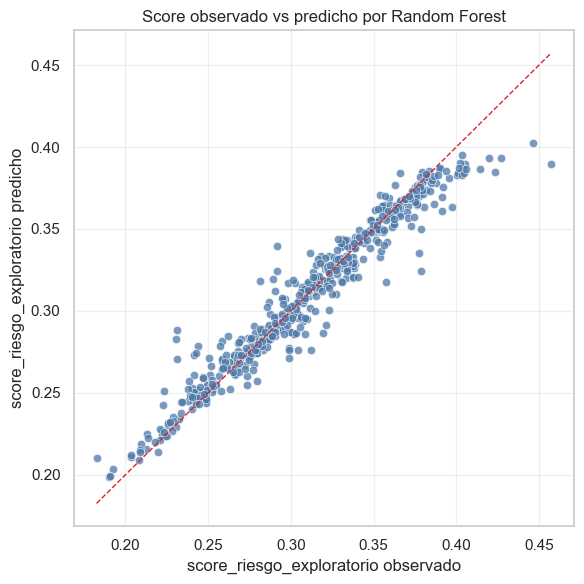

In [30]:
rf_target_col = "score_riesgo_exploratorio"
rf_features = model_features.copy()

X_rf = X_model[rf_features].copy()
y_rf = df_mun[rf_target_col].copy()

assert y_rf.isna().sum() == 0, "El target del Random Forest no puede contener nulos."
assert X_rf.isna().sum().sum() == 0, "Las variables del Random Forest no pueden contener nulos."

X_train, X_test, y_train, y_test = train_test_split(
    X_rf,
    y_rf,
    test_size=0.25,
    random_state=42,
)

rf_score_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=1,
    oob_score=True,
)
rf_score_model.fit(X_train, y_train)

rf_pred_train = rf_score_model.predict(X_train)
rf_pred_test = rf_score_model.predict(X_test)
rf_pred_all = rf_score_model.predict(X_rf)

df_mun["rf_score_riesgo_pred"] = rf_pred_all
df_mun["rf_score_riesgo_residuo"] = df_mun[rf_target_col] - df_mun["rf_score_riesgo_pred"]
df_mun["rf_score_riesgo_error_abs"] = df_mun["rf_score_riesgo_residuo"].abs()

rf_metrics = pd.DataFrame(
    [
        {
            "metrica": "R2 train",
            "valor": r2_score(y_train, rf_pred_train),
        },
        {
            "metrica": "R2 test",
            "valor": r2_score(y_test, rf_pred_test),
        },
        {
            "metrica": "MAE train",
            "valor": mean_absolute_error(y_train, rf_pred_train),
        },
        {
            "metrica": "MAE test",
            "valor": mean_absolute_error(y_test, rf_pred_test),
        },
        {
            "metrica": "R2 out-of-bag",
            "valor": rf_score_model.oob_score_,
        },
        {
            "metrica": "MAE total",
            "valor": mean_absolute_error(y_rf, rf_pred_all),
        },
    ]
)

rf_metrics.to_csv(MODEL_OUT / "rf_score_metrics.csv", index=False)

print("Random Forest explicativo del score exploratorio")
display(rf_metrics.round(4))

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_rf, y=rf_pred_all, color="#4c78a8", alpha=0.75)
min_val = min(y_rf.min(), rf_pred_all.min())
max_val = max(y_rf.max(), rf_pred_all.max())
plt.plot([min_val, max_val], [min_val, max_val], color="#d62728", linestyle="--", linewidth=1)
plt.title("Score observado vs predicho por Random Forest")
plt.xlabel("score_riesgo_exploratorio observado")
plt.ylabel("score_riesgo_exploratorio predicho")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Importancia de variables guardada en: C:\Users\gonza\OneDrive\tfg\output\modelado\rf_score_feature_importance.csv


,variable,importancia_rf,bloque,dimension,origen,importancia_permutacion_media,importancia_permutacion_std
0,precip_p99,0.3510,peligro_climatico_base,Amenaza climatica directa,ERA5-Land base,0.5380,0.0670
1,dias_calor_intenso,0.1634,peligro_climatico_base,Amenaza climatica directa,ERA5-Land base,0.2593,0.0268
2,mayores_65_pct,0.0535,vulnerabilidad_social,Vulnerabilidad territorial,INE,0.0911,0.0155
3,dias_radiacion_alta,0.0771,contexto_climatico_extendido,Contexto fisico complementario,ERA5-Land extendido,0.0884,0.0144
4,renta_media_hogar,0.0411,vulnerabilidad_social,Vulnerabilidad territorial,INE,0.0391,0.0057
5,viento_p95,0.0596,peligro_climatico_base,Amenaza climatica directa,ERA5-Land base,0.0364,0.0104
6,altitud_m,0.0320,condicion_fisica,Control territorial,Open-Meteo/IGN,0.0304,0.0075
7,snczi_inundacion_t500_pct_area_aprox,0.0209,exposicion_inundacion_snczi,Exposicion hidrologica territorial,SNCZI / IDEE,0.0260,0.0044
8,temp_p95,0.0489,peligro_climatico_base,Amenaza climatica directa,ERA5-Land base,0.0254,0.0071
9,dias_suelo_seco,0.0202,contexto_climatico_extendido,Contexto fisico complementario,ERA5-Land extendido,0.0186,0.0037


,bloque,dimension,importancia_rf,importancia_permutacion_media
4,peligro_climatico_base,Amenaza climatica directa,0.6266,0.8608
5,vulnerabilidad_social,Vulnerabilidad territorial,0.1119,0.1319
1,contexto_climatico_extendido,Contexto fisico complementario,0.1334,0.1187
3,exposicion_inundacion_snczi,Exposicion hidrologica territorial,0.0292,0.0325
0,condicion_fisica,Control territorial,0.0320,0.0304
2,exposicion_fisica_catastro,Exposicion construida,0.0670,0.0182


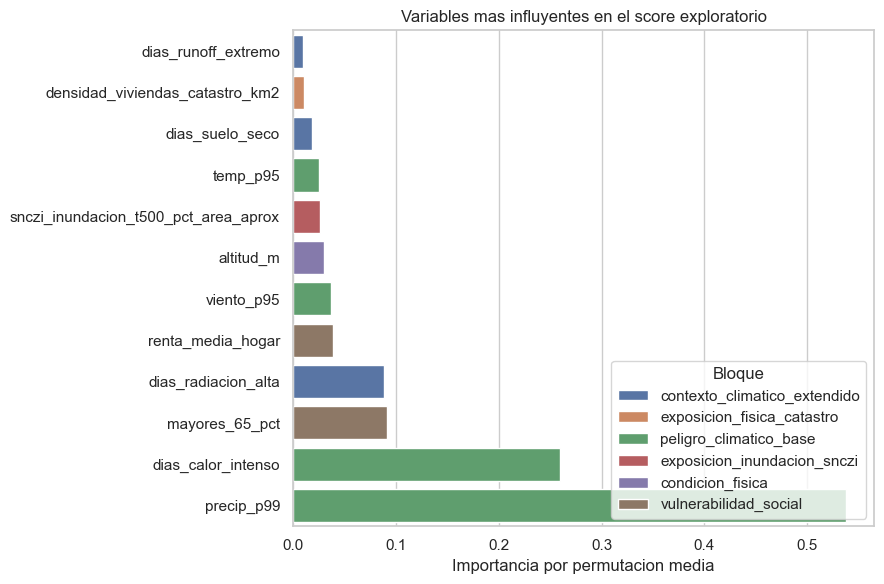

In [31]:
feature_metadata = feature_catalog[["variable", "bloque", "dimension", "origen"]].drop_duplicates("variable")

rf_importance = pd.DataFrame(
    {
        "variable": rf_features,
        "importancia_rf": rf_score_model.feature_importances_,
    }
).merge(feature_metadata, on="variable", how="left")

permutation = permutation_importance(
    rf_score_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=1,
    scoring="r2",
)

permutation_importance_df = pd.DataFrame(
    {
        "variable": rf_features,
        "importancia_permutacion_media": permutation.importances_mean,
        "importancia_permutacion_std": permutation.importances_std,
    }
)

rf_importance = (
    rf_importance
    .merge(permutation_importance_df, on="variable", how="left")
    .sort_values("importancia_permutacion_media", ascending=False)
    .reset_index(drop=True)
)

rf_importance_file = MODEL_OUT / "rf_score_feature_importance.csv"
rf_importance.to_csv(rf_importance_file, index=False)

print("Importancia de variables guardada en:", rf_importance_file)
display(rf_importance.round(4))

block_importance = (
    rf_importance.groupby(["bloque", "dimension"], as_index=False)
    .agg(
        importancia_rf=("importancia_rf", "sum"),
        importancia_permutacion_media=("importancia_permutacion_media", "sum"),
    )
    .sort_values("importancia_permutacion_media", ascending=False)
)

display(block_importance.round(4))

plt.figure(figsize=(9, 6))
top_importance = rf_importance.head(12).sort_values("importancia_permutacion_media")
sns.barplot(
    data=top_importance,
    x="importancia_permutacion_media",
    y="variable",
    hue="bloque",
    dodge=False,
)
plt.title("Variables mas influyentes en el score exploratorio")
plt.xlabel("Importancia por permutacion media")
plt.ylabel("")
plt.legend(title="Bloque", loc="lower right")
plt.tight_layout()
plt.show()

In [32]:
try:
    import shap

    shap_explainer = shap.TreeExplainer(rf_score_model)
    shap_values = shap_explainer.shap_values(X_rf)

    shap_importance = pd.DataFrame(
        {
            "variable": rf_features,
            "importancia_shap_media_abs": np.abs(shap_values).mean(axis=0),
        }
    ).merge(feature_metadata, on="variable", how="left")

    shap_importance = shap_importance.sort_values(
        "importancia_shap_media_abs",
        ascending=False,
    ).reset_index(drop=True)

    shap_importance_file = MODEL_OUT / "rf_score_shap_importance.csv"
    shap_importance.to_csv(shap_importance_file, index=False)

    print("Importancia SHAP guardada en:", shap_importance_file)
    display(shap_importance.head(15).round(4))
except ImportError:
    print(
        "SHAP no esta instalado en el entorno actual. "
        "Se deja el bloque preparado, pero la explicabilidad principal se basa en permutation importance."
    )
except Exception as exc:
    print("No se pudo calcular SHAP en esta ejecucion:", exc)

SHAP no esta instalado en el entorno actual. Se deja el bloque preparado, pero la explicabilidad principal se basa en permutation importance.


La lectura del `Random Forest` debe mantenerse dentro de su alcance: el modelo aprende a reproducir el indice exploratorio construido con datos abiertos, no a predecir siniestros reales. Aun asi, aporta valor porque permite comprobar si la priorizacion del score esta dominada por unas pocas variables o si combina varios bloques de informacion.

La importancia por permutacion es especialmente util porque mide cuanto empeora el modelo al alterar cada variable en el conjunto de prueba. Si variables de `ERA5-Land`, `Catastro`, `SNCZI` e `INE` aparecen entre las mas relevantes, se refuerza la idea de que el indice combina peligro, exposicion y vulnerabilidad. Si una unica familia dominase por completo, habria que revisar la ponderacion del score antes de trasladarlo a negocio.

El bloque SHAP queda preparado como extension opcional. En esta ejecucion no se fuerza su instalacion para no modificar dependencias del proyecto antes de cerrar `requirements.txt`.

## 11. Exportacion de la base municipal segmentada

Como salida del proceso de modelado, se guarda una version de la tabla municipal analitica enriquecida con las etiquetas de cluster generadas por `KMeans`, `Agglomerative Clustering` y el contraste exploratorio `DBSCAN`. Este fichero facilita la continuidad hacia el siguiente cuaderno, ya que permite reutilizar directamente la segmentacion obtenida sin necesidad de recalcular los modelos.

La base exportada conserva los indicadores climaticos, territoriales, sociales, de Catastro y de `SNCZI` del `Notebook 3`, incorpora la proyeccion `PCA` de diagnostico, conserva la descomposicion del score exploratorio del `Notebook 3`, anade las variables `cluster_kmeans`, `cluster_agg` y `cluster_dbscan`, e incluye las predicciones auxiliares del Random Forest explicativo (`rf_score_riesgo_pred`, `rf_score_riesgo_residuo`, `rf_score_riesgo_error_abs`). La variable operativa principal para negocio sigue siendo `cluster_kmeans`; las otras dos se conservan como contraste y trazabilidad metodologica.

In [33]:
df_mun.to_csv(SEGMENTED_MUNICIPAL_FILE, index=False)

print("Base municipal segmentada guardada en:", SEGMENTED_MUNICIPAL_FILE)
print("Shape:", df_mun.shape)
print("Columnas:", len(df_mun.columns))
print("Duplicados municipales:", df_mun.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum())
print("Municipios sin cluster KMeans:", df_mun["cluster_kmeans"].isna().sum())
print("Municipios sin cluster Agglomerative:", df_mun["cluster_agg"].isna().sum())
print("Municipios sin etiqueta DBSCAN:", df_mun["cluster_dbscan"].isna().sum())
print("Municipios marcados como ruido por DBSCAN:", (df_mun["cluster_dbscan"] == -1).sum())

assert SEGMENTED_MUNICIPAL_FILE.exists(), "No se ha generado la salida segmentada."
assert len(df_mun) == 542, "La salida segmentada debe tener una fila por municipio."
assert df_mun.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum() == 0, "La salida segmentada contiene duplicados."
assert df_mun["cluster_kmeans"].isna().sum() == 0, "Hay municipios sin cluster KMeans."
assert df_mun["cluster_agg"].isna().sum() == 0, "Hay municipios sin cluster Agglomerative."
assert df_mun["cluster_dbscan"].isna().sum() == 0, "Hay municipios sin etiqueta DBSCAN."

model_artifacts_manifest = pd.DataFrame(
    [
        {
            "artefacto": "dataset_cv_municipios_segmentado.csv",
            "ruta": str(SEGMENTED_MUNICIPAL_FILE.relative_to(ROOT)),
            "contenido": "Dataset municipal con etiquetas KMeans, Agglomerative, DBSCAN, PCA y predicciones auxiliares RF.",
            "uso_posterior": "Entrada principal del Notebook 5 de analisis de negocio.",
        },
        {
            "artefacto": "model_feature_catalog.csv",
            "ruta": "output/modelado/model_feature_catalog.csv",
            "contenido": "Variables observables usadas para entrenar KMeans, Agglomerative y Random Forest explicativo.",
            "uso_posterior": "Justificar seleccion de variables y excluir scores compuestos del entrenamiento.",
        },
        {
            "artefacto": "model_feature_exclusions.csv",
            "ruta": "output/modelado/model_feature_exclusions.csv",
            "contenido": "Familias de variables excluidas del entrenamiento y motivo metodologico.",
            "uso_posterior": "Defender que el modelo no replica directamente el score heuristico ni usa trazabilidad tecnica.",
        },
        {
            "artefacto": "model_preprocessing_audit.csv",
            "ruta": "output/modelado/model_preprocessing_audit.csv",
            "contenido": "Nulos, imputacion, transformaciones logaritmicas y estadisticos tras preprocesado.",
            "uso_posterior": "Auditar la matriz de modelado antes de segmentacion y Random Forest.",
        },
        {
            "artefacto": "model_comparison.csv",
            "ruta": "output/modelado/model_comparison.csv",
            "contenido": "Metricas comparadas de KMeans, Agglomerative y DBSCAN.",
            "uso_posterior": "Sostener la seleccion del enfoque principal de segmentacion.",
        },
        {
            "artefacto": "model_selection_summary.csv",
            "ruta": "output/modelado/model_selection_summary.csv",
            "contenido": "Papel metodologico de cada modelo y decision de uso dentro del TFG.",
            "uso_posterior": "Explicar por que KMeans es principal y los otros modelos son contraste.",
        },
        {
            "artefacto": "model_selection_rationale.csv",
            "ruta": "output/modelado/model_selection_rationale.csv",
            "contenido": "Criterios cualitativos usados para elegir el modelo principal.",
            "uso_posterior": "Complementar las metricas internas con interpretabilidad y utilidad de negocio.",
        },
        {
            "artefacto": "rf_score_metrics.csv",
            "ruta": "output/modelado/rf_score_metrics.csv",
            "contenido": "Metricas del Random Forest explicativo del score exploratorio.",
            "uso_posterior": "Documentar que el modelo explica el indice, no siniestralidad real.",
        },
        {
            "artefacto": "rf_score_feature_importance.csv",
            "ruta": "output/modelado/rf_score_feature_importance.csv",
            "contenido": "Importancias RF y permutation importance por variable y bloque.",
            "uso_posterior": "Responder que variables observables influyen mas en el score exploratorio.",
        },
    ]
)
model_artifacts_manifest["existe"] = model_artifacts_manifest["ruta"].apply(lambda ruta: (ROOT / ruta).exists())
model_artifacts_manifest.to_csv(MODEL_OUT / "manifest_artefactos_modelado.csv", index=False)

print("Manifest de artefactos de modelado guardado en:", MODEL_OUT / "manifest_artefactos_modelado.csv")
display(model_artifacts_manifest)

display(df_mun[["municipio", "cluster_kmeans", "cluster_agg", "cluster_dbscan", "score_riesgo_exploratorio", "dimension_dominante_score"]].head())

Base municipal segmentada guardada en: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_segmentado.csv
Shape: (542, 118)
Columnas: 118
Duplicados municipales: 0
Municipios sin cluster KMeans: 0
Municipios sin cluster Agglomerative: 0
Municipios sin etiqueta DBSCAN: 0
Municipios marcados como ruido por DBSCAN: 59
Manifest de artefactos de modelado guardado en: C:\Users\gonza\OneDrive\tfg\output\modelado\manifest_artefactos_modelado.csv


,artefacto,ruta,contenido,uso_posterior,existe
0,dataset_cv_municipios_segmentado.csv,DATA\PROCESSED\dataset_cv_municipios_segmentad...,"Dataset municipal con etiquetas KMeans, Agglom...",Entrada principal del Notebook 5 de analisis d...,True
1,model_feature_catalog.csv,output/modelado/model_feature_catalog.csv,Variables observables usadas para entrenar KMe...,Justificar seleccion de variables y excluir sc...,True
2,model_feature_exclusions.csv,output/modelado/model_feature_exclusions.csv,Familias de variables excluidas del entrenamie...,Defender que el modelo no replica directamente...,True
3,model_preprocessing_audit.csv,output/modelado/model_preprocessing_audit.csv,"Nulos, imputacion, transformaciones logaritmic...",Auditar la matriz de modelado antes de segment...,True
4,model_comparison.csv,output/modelado/model_comparison.csv,"Metricas comparadas de KMeans, Agglomerative y...",Sostener la seleccion del enfoque principal de...,True
5,model_selection_summary.csv,output/modelado/model_selection_summary.csv,Papel metodologico de cada modelo y decision d...,Explicar por que KMeans es principal y los otr...,True
6,model_selection_rationale.csv,output/modelado/model_selection_rationale.csv,Criterios cualitativos usados para elegir el m...,Complementar las metricas internas con interpr...,True
7,rf_score_metrics.csv,output/modelado/rf_score_metrics.csv,Metricas del Random Forest explicativo del sco...,"Documentar que el modelo explica el indice, no...",True
8,rf_score_feature_importance.csv,output/modelado/rf_score_feature_importance.csv,Importancias RF y permutation importance por v...,Responder que variables observables influyen m...,True


,municipio,cluster_kmeans,cluster_agg,cluster_dbscan,score_riesgo_exploratorio,dimension_dominante_score
0,Ademuz,1,0,-1,0.244092,vulnerabilidad
1,Ador,2,2,0,0.366768,peligro climatico
2,Agost,3,1,0,0.301895,peligro climatico
3,Agres,2,0,0,0.310747,peligro climatico
4,Agullent,2,3,0,0.312086,peligro climatico


## 12. Conclusiones del modelado y continuidad hacia Analisis de Negocio

La fase de modelado desarrollada en este cuaderno permite comprobar que el dataset municipal construido en las fases anteriores no solo es util para el analisis descriptivo, sino tambien para la identificacion de patrones territoriales mediante tecnicas de segmentacion no supervisada. La aplicacion de distintos modelos y su comparacion posterior permiten avanzar desde una lectura exploratoria del territorio hacia una clasificacion mas estructurada de perfiles municipales.

La segmentacion actual aprovecha ya las mejoras incorporadas en la fase anterior: variables climaticas extendidas de `ERA5-Land`, indicadores de exposicion edificada de Catastro, exposicion a inundacion de `SNCZI` y variables sociales y economicas del INE. Esto permite que los clusters no dependan solo de precipitacion, temperatura y viento, sino tambien de dimensiones fisicas, hidrologicas y territoriales relevantes para un problema de riesgo asegurador.

La descomposicion del score por cluster ayuda a explicar si la priorizacion de cada grupo procede principalmente de peligro climatico, vulnerabilidad territorial o exposicion fisica. Los resultados obtenidos deben interpretarse con cautela, ya que los clusters construidos no representan categorias absolutas ni equivalen directamente a niveles reales de siniestralidad. No obstante, si resultan utiles para detectar combinaciones recurrentes de intensidad climatica, exposicion y vulnerabilidad territorial, lo que aporta valor analitico al TFG incluso en ausencia de datos internos de siniestros.

Ademas, el Random Forest explicativo permite recuperar parte del planteamiento del anteproyecto sobre modelos basados en arboles e importancia de variables, manteniendo la cautela de que se explica un indice exploratorio y no siniestralidad real. En esta fase, `KMeans` se selecciona como enfoque principal por ofrecer una solucion equilibrada e interpretable. `Agglomerative Clustering` queda como contraste de estabilidad metodologica y `DBSCAN` como lectura auxiliar de concentraciones espaciales y municipios singulares. Esta separacion de papeles evita sobredimensionar el modelado y mantiene una narrativa coherente: un modelo principal para segmentar, un contraste jerarquico para comparar y una prueba de densidad para enriquecer la lectura territorial.

A partir de esta base segmentada, la siguiente fase del proyecto consiste en traducir los hallazgos del modelado a una interpretacion orientada a negocio.

Esto implica valorar que perfiles municipales resultan mas relevantes desde la perspectiva aseguradora, que implicaciones pueden tener para priorizacion analitica, prevencion o gestion territorial de la cartera, y que limitaciones deben tenerse presentes antes de extraer conclusiones aplicadas.